# Signal Test Replication

This notebook is the educational entry point for the whitepaper signal section. The goal of this part of the paper is simple: describe the state of the VIX futures curve by counting how many of the first seven contracts are out of their usual contango order, then study how equity and volatility allocations behave in those regimes.

What this notebook currently covers from the whitepaper:
- Figures 1, 2, and 8 style term-structure snapshots.
- The Figure 3 style bucket test using equity proxies.
- The signal pipeline that later feeds Cuttlefish, Squid, Giant Squid, Jumbo Squid, and Colossal Squid.
- Exporting daily strategy weights as investable outputs.

Locked conventions for this repo implementation:
- `settle_expiry_roll` drives the signal.
- `settle` is reserved for PnL accountability.
- `ES=F` and `SPY` are compared side by side as equity proxies.
- Spot VIX is only used for the refined `Vc` filter.
- A clean bundled `SPVXTSTR` file is stored at `data/external/spvxtstr_normalized.csv`.

Important implementation note: the text around Eq. (4) clearly treats `w` as the equity weight, so in code we implement the intended behavior as `w_es = 1 - dislocations / 7`, which makes the ES allocation largest in perfect contango and smallest when the curve is highly scrambled or inverted.


## Notebook Roadmap

Each section below is meant to answer one concrete question from the whitepaper:
1. What data and parameter choices are we using for replication?
2. How do we split signal generation from tradable PnL accounting?
3. What do the reference term structures look like on the paper's example dates?
4. Do equity returns behave differently across dislocation buckets?
5. How does that signal translate into actual program weights?
6. How do we prepare `SPVXTSTR` so later sections can compare equity and volatility directly?


## 1. Environment And Parameters

This cell sets the notebook's working assumptions. It locates the repo root, points to the cleaned VX ladder, points to the Bloomberg `SPVXTSTR` export, and fixes the sample window used in the paper (`2006-04-05` through `2025-12-31`). It also exposes the refined-model thresholds as explicit parameters so we can later test different values without changing the core logic.


In [270]:
from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

from squid_replication.signals import (
    DEFAULT_BUCKET_ORDER,
    DEFAULT_END,
    DEFAULT_START,
    build_base_program_weights,
    build_drawdown_series,
    build_daily_signal_frame,
    build_generic_return_frame,
    build_growth_index,
    build_refined_program_weights,
    build_return_frame_from_levels,
    build_spvxtstr_program_weights,
    build_term_structure,
    build_turnover_series,
    build_weekly_signal_frame,
    combine_weighted_returns,
    extract_extreme_moves,
    load_spvxtstr_history,
    load_spot_vix_history,
    summarize_performance,
    summarize_bucket_returns,
    summarize_conditional_returns,
)


# Walk up from the notebook directory until we find the project root.
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('Could not find repo root from current working directory.')


# Paths and parameters are defined once here so every later cell stays deterministic.
ROOT = find_repo_root(Path.cwd().resolve())
DATA_DIR = ROOT / 'data'
GENERIC_PATH = DATA_DIR / 'clean' / 'vix_futures' / 'generic_contracts.parquet'
SPVXTSTR_PATH = DATA_DIR / 'external' / 'spvxtstr_normalized.csv'
EXPORT_DIR = DATA_DIR / 'derived'

SLOPE_THRESHOLD = -0.10
VIX_THRESHOLD = 30.0
VX_PNL_MODE = 'generic_net_return'
VX_PNL_PRICE_FIELD = 'settle_expiry_roll'
PROXY_CANDIDATES = ['ES=F', 'SPY']
PRIMARY_EQUITY_PROXY = 'ES=F'
START = DEFAULT_START
END = DEFAULT_END

plt.rcParams['figure.dpi'] = 180
plt.rcParams['figure.figsize'] = (10, 5)

ROOT


WindowsPath('C:/Users/rodri/git/squid-replication')

## 2. Build The Whitepaper Signal

This is the main construction cell. We load the cleaned generic VX ladder, then deliberately build two different curve views:
- `signal_curve` from `settle_expiry_roll`: this is the smoother hold-through-expiry ladder we use to classify the term structure into contango and dislocation regimes.
- `pnl_curve` from a configurable VX price field: for this test pass it uses `settle_expiry_roll`, which we keep available for comparison and alternate PnL experiments.

We also load official spot VIX from Cboe because the refined models in the paper use an absolute VIX threshold `Vc` in addition to the relative curve shape. Finally, we build both the daily and weekly signal frames and translate them into program weights.


In [271]:
generic_frame = pd.read_parquet(GENERIC_PATH)

# Signal generation uses the expiry-roll ladder, as discussed in the whitepaper replication plan.
signal_curve = build_term_structure(
    generic_frame,
    price_field='settle_expiry_roll',
    start=START,
    end=END,
    forward_fill=True,
)
# VX PnL inputs are configurable; for this test we use the expiry-roll settle ladder as well.
pnl_curve = build_term_structure(
    generic_frame,
    price_field=VX_PNL_PRICE_FIELD,
    start=START,
    end=END,
    forward_fill=False,
)

vix_history = load_spot_vix_history()
vix_close = vix_history['vix_close'].reindex(signal_curve.index)

# Daily signals use yesterday's curve state. Weekly signals use the previous completed week's average curve state.
daily_signal = build_daily_signal_frame(signal_curve, vix_close=vix_close)
weekly_signal = build_weekly_signal_frame(signal_curve, vix_close=vix_close)

# Base models allocate between ES and the simplified volatility allocation VA = -0.5 * UX1 + UX3.
daily_base_weights = build_base_program_weights(daily_signal, name='Cuttlefish')
weekly_base_weights = build_base_program_weights(weekly_signal, name='Squid')
# Refined models add the slope filter and the spot-VIX filter from the later whitepaper section.
daily_refined_weights = build_refined_program_weights(
    daily_signal,
    name='Colossal Squid',
    slope_threshold=SLOPE_THRESHOLD,
    vix_threshold=VIX_THRESHOLD,
    allow_short_es=True,
)
weekly_refined_weights = build_refined_program_weights(
    weekly_signal,
    name='Giant Squid',
    slope_threshold=SLOPE_THRESHOLD,
    vix_threshold=VIX_THRESHOLD,
    allow_short_es=True,
)
weekly_long_only_weights = build_refined_program_weights(
    weekly_signal,
    name='Jumbo Squid',
    slope_threshold=SLOPE_THRESHOLD,
    vix_threshold=VIX_THRESHOLD,
    allow_short_es=False,
)

daily_signal[[
    'dislocation_count_raw',
    'dislocation_bucket_raw',
    'es_weight_signal',
    'slope_signal',
    'vix_close_signal',
]].head()


,dislocation_count_raw,dislocation_bucket_raw,es_weight_signal,slope_signal,vix_close_signal
trade_date,,,,,
2006-04-05,3,Low Dislocation (2-4),<NA>,NaN,NaN
2006-04-06,3,Low Dislocation (2-4),0.571429,0.242521,11.13
2006-04-07,3,Low Dislocation (2-4),0.571429,0.241248,11.45
2006-04-10,3,Low Dislocation (2-4),0.571429,0.231700,12.26
2006-04-11,3,Low Dislocation (2-4),0.571429,0.217059,12.19


In [272]:
summary = pd.DataFrame(
    {
        'metric': [
            'Generic VX rows',
            'Signal dates',
            'PnL dates',
            'First signal date',
            'Last signal date',
            'Spot VIX observations aligned to signal dates',
        ],
        'value': [
            f'{len(generic_frame):,}',
            f'{len(signal_curve):,}',
            f"{len(pnl_curve.dropna(how='all')):,}",
            signal_curve.index.min().date(),
            signal_curve.index.max().date(),
            f'{vix_close.notna().sum():,}',
        ],
    }
)
summary


,metric,value
0,Generic VX rows,"36,287"
1,Signal dates,"4,970"
2,PnL dates,"4,970"
3,First signal date,2006-04-05
4,Last signal date,2025-12-31
5,Spot VIX observations aligned to signal dates,"4,968"


## 3. Refined-Model Thresholds

The whitepaper introduces two extra regime filters after the base signal test:
- `mc`: a negative slope cutoff used to dampen volatility exposure when the curve is only mildly inverted.
- `Vc`: a spot-VIX cutoff used to increase volatility exposure when absolute volatility is high even if the curve is not strongly inverted.

The excerpt we are working from does not lock those to one canonical pair of values, so the notebook keeps them as explicit parameters. That makes the notebook educational and reproducible, while still letting us calibrate them later against the paper's final reported equity curves.


## 4. Bucket Counts

Before looking at returns, we first inspect how often each regime occurs in our replication sample. This is the structural sanity check behind Table 2 in the paper. If the bucket counts are wildly off, then either the curve construction or the date alignment is wrong.


In [273]:
daily_signal['dislocation_bucket_raw'].value_counts(dropna=False)


dislocation_bucket_raw
Perfect Contango (0)      2692
High Dislocation (5-7)    1285
Low Dislocation (2-4)      898
<NA>                        95
Name: count, dtype: int64

## 5. Term-Structure Snapshots

The paper motivates the signal visually before moving to bucket tests. These plots show what the UX curve looks like in three representative states:
- normal contango, where UX1 < UX2 < ... < UX7,
- crisis-style backwardation, where the front of the curve is bid aggressively,
- a flat or scrambled curve, where the ordering is not clean even though absolute differences may be small.

These are direct checks that our cleaned VX ladder behaves the way the whitepaper describes.


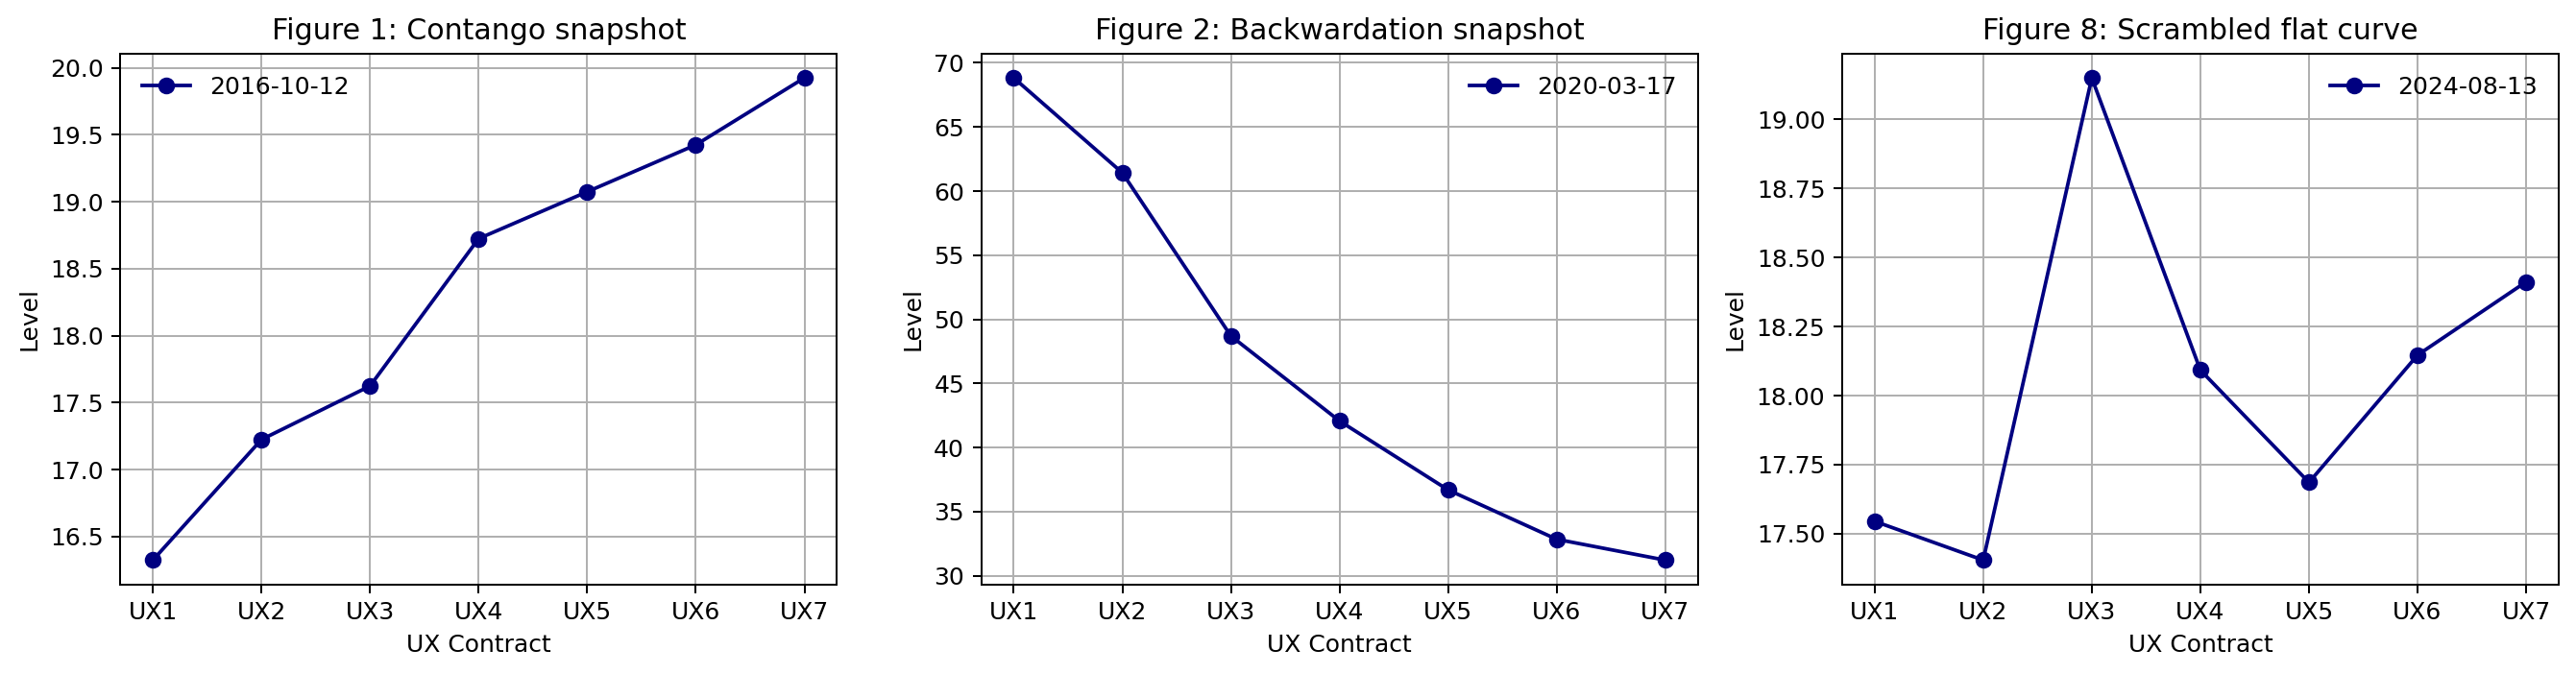

In [274]:
snapshot_map = {
    'Figure 1: Contango snapshot': '2016-10-12',
    'Figure 2: Backwardation snapshot': '2020-03-17',
    'Figure 8: Scrambled flat curve': '2024-08-13',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (title, trade_date) in zip(axes, snapshot_map.items()):
    signal_curve.loc[trade_date].plot(ax=ax, marker='o', grid=True, color='navy')
    ax.set_title(title)
    ax.set_xlabel('UX Contract')
    ax.set_ylabel('Level')
    ax.legend([trade_date], frameon=False)
plt.tight_layout()


## 6. Equity Proxy Data

The paper uses ES futures, but our first replication pass compares two practical Yahoo-based proxies:
- `ES=F`, which is instrumentally closer to the paper,
- `SPY`, which is a useful sanity-check series when futures data quality is awkward.

This cell pulls raw close data, aligns it to the VX signal calendar, and computes close-to-close returns. At this stage we are not trying to perfectly reproduce the ES roll methodology from the paper yet; we are trying to see which proxy gets us closer to the signal-test behavior.


In [275]:
def fetch_proxy_close(ticker: str) -> pd.Series:
    # Yahoo returns a daily close series; later we can swap this out for a stricter ES roll implementation.
    history = yf.download(
        ticker,
        start=START.strftime('%Y-%m-%d'),
        end=(END + pd.Timedelta(days=1)).strftime('%Y-%m-%d'),
        auto_adjust=False,
        progress=False,
    )
    if history.empty:
        raise ValueError(f'No history returned for {ticker}.')
    if isinstance(history.columns, pd.MultiIndex):
        history.columns = history.columns.get_level_values(0)
    close = history['Close'].rename(ticker)
    close.index = pd.to_datetime(close.index)
    return close.sort_index()


proxy_close = pd.concat([fetch_proxy_close('ES=F'), fetch_proxy_close('SPY')], axis=1)
proxy_close = proxy_close.reindex(signal_curve.index).ffill()
proxy_returns = proxy_close.pct_change()
proxy_close.tail()


C:\Users\rodri\AppData\Local\Temp\ipykernel_32088\628767835.py:19: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  proxy_close = pd.concat([fetch_proxy_close('ES=F'), fetch_proxy_close('SPY')], axis=1)


,ES=F,SPY
trade_date,,
2025-12-24,6982.50,690.380005
2025-12-26,6979.25,690.309998
2025-12-29,6955.00,687.849976
2025-12-30,6944.25,687.010010
2025-12-31,6892.50,681.919983


## 7. Same-Day Bucket Test (Figure 3 Style)

This is the paper's first core result: take today's VIX-curve state, bucket it by dislocations, and compare average same-day equity returns across those buckets. We keep this separate from the tradable `t-1 -> t` logic because the whitepaper also treats these as two different questions.

Interpretation:
- if perfect contango has the best average equity return, the signal is behaving as expected,
- if high dislocations have poor or unstable equity returns, the case for switching into a volatility allocation becomes stronger.


,count,ES=F,SPY
dislocation_bucket,,,
Perfect Contango (0),2692,0.001103,0.001103
Low Dislocation (2-4),897,0.001183,0.001144
High Dislocation (5-7),1285,-0.001544,-0.001490


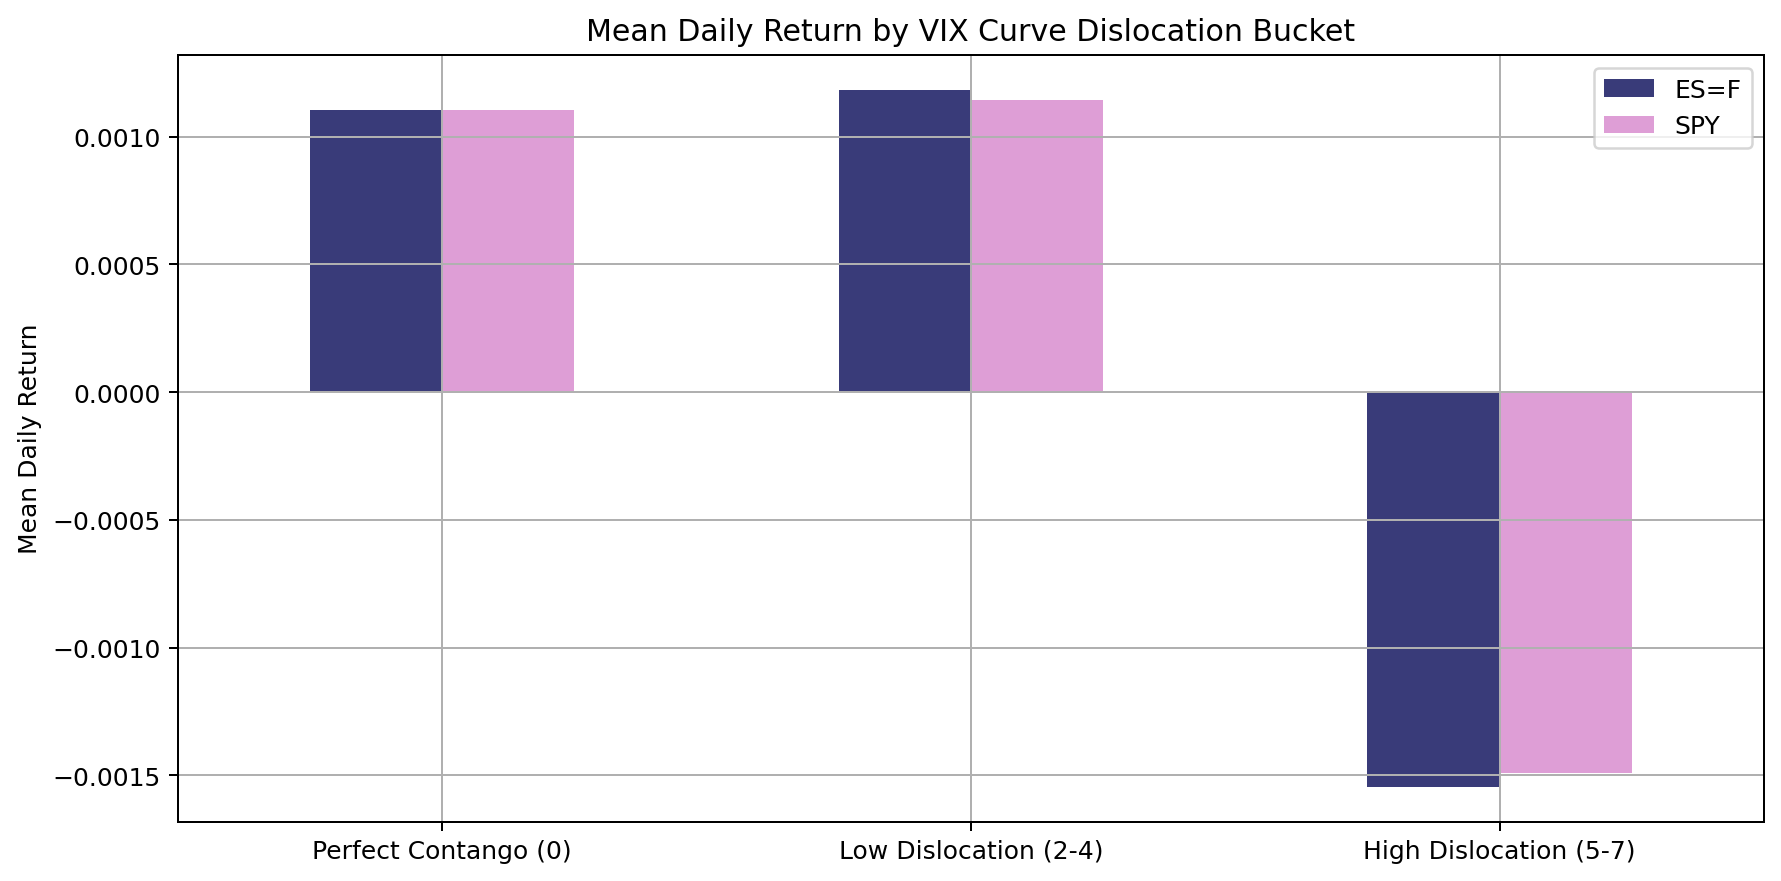

In [276]:
bucketed_returns = summarize_bucket_returns(
    proxy_returns[['ES=F', 'SPY']],
    daily_signal['dislocation_bucket_raw'],
)

ax = bucketed_returns[['ES=F', 'SPY']].plot(kind='bar', grid=True, cmap='tab20b')
ax.set_title('Mean Daily Return by VIX Curve Dislocation Bucket')
ax.set_ylabel('Mean Daily Return')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()

bucketed_returns


## 8. From Signal To Strategy Weights

The paper's strategies are not just descriptive charts; they are investable allocation rules. This plot shows that transition directly. The green line is the ES weight for the daily base program (`Cuttlefish`), while the red series is the raw number of daily dislocations. When the curve is orderly and in contango, the strategy leans into equity. When the curve becomes inverted or scrambled, the ES weight falls and the volatility allocation takes over.


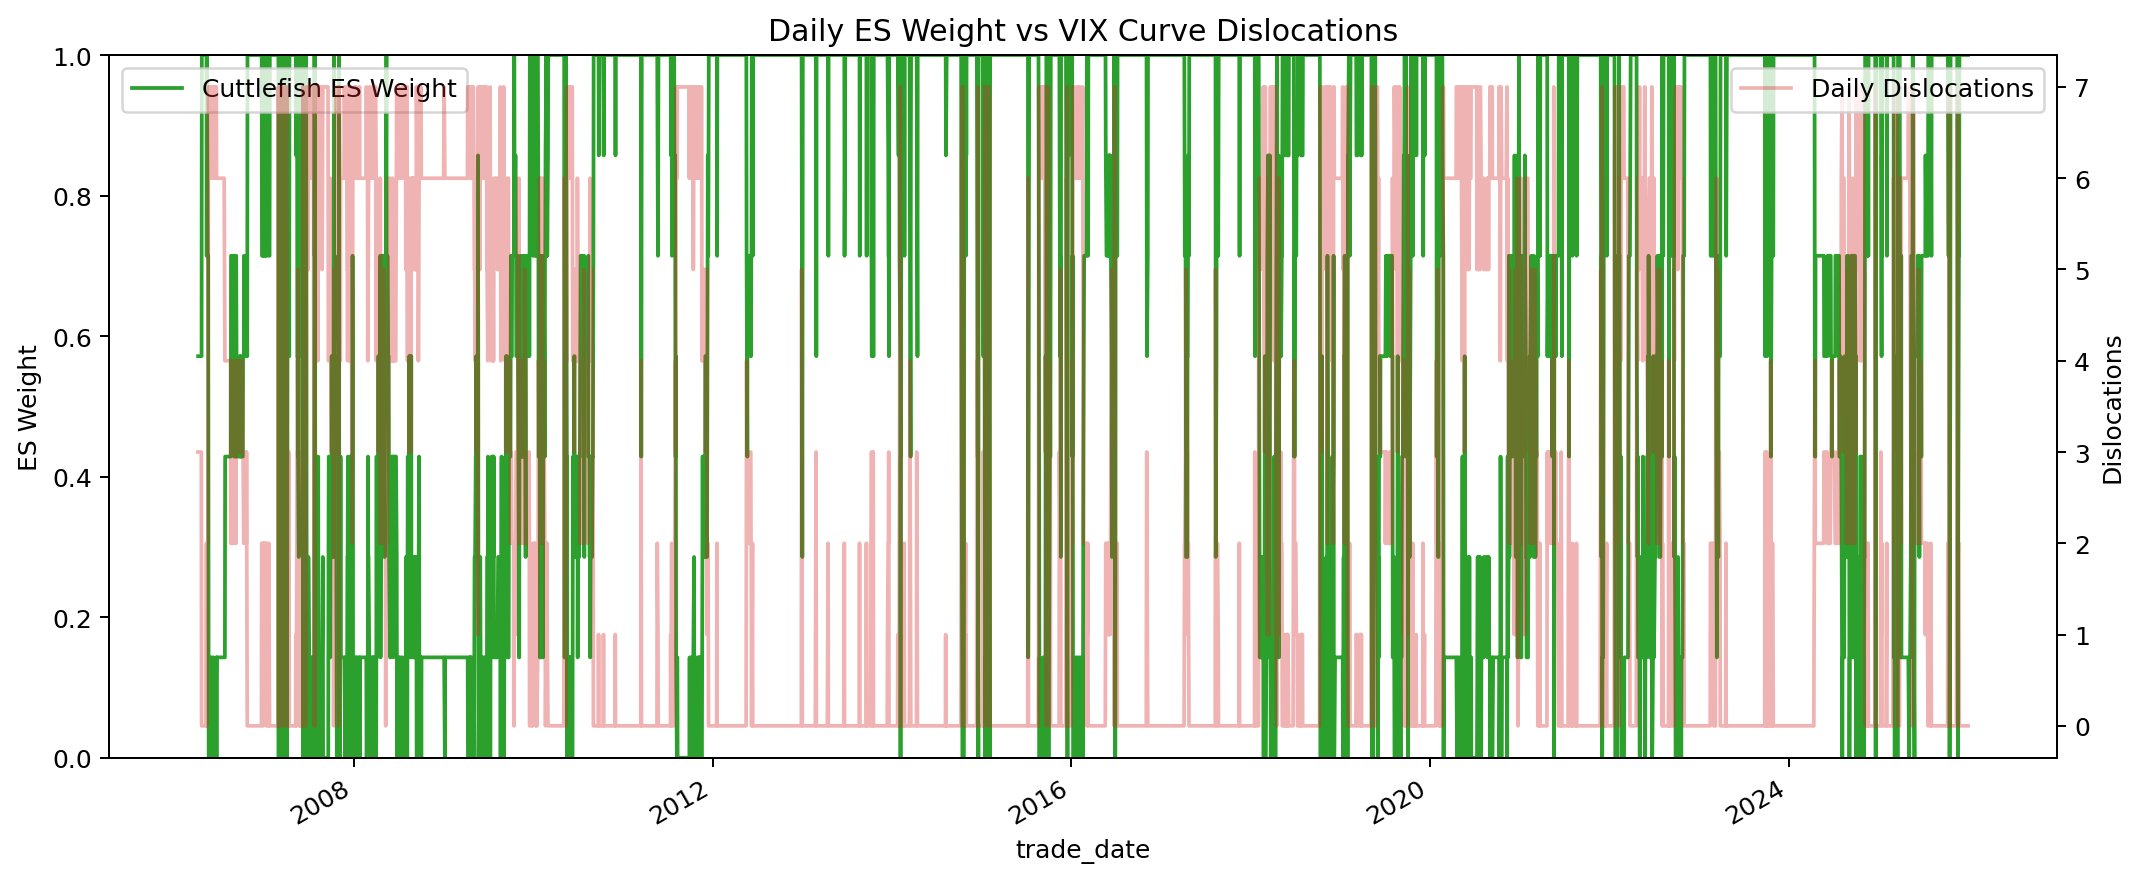

In [277]:
fig, ax1 = plt.subplots(figsize=(12, 5))
daily_base_weights['weight_es'].plot(ax=ax1, color='tab:green', label='Cuttlefish ES Weight')
ax1.set_ylabel('ES Weight')
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
daily_signal['dislocation_count_raw'].astype(float).plot(
    ax=ax2,
    color='tab:red',
    alpha=0.35,
    label='Daily Dislocations',
)
ax2.set_ylabel('Dislocations')

ax1.set_title('Daily ES Weight vs VIX Curve Dislocations')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()


## 9. Normalized SPVXTSTR Input

Later sections of the paper compare ES to the S&P 500 VIX Futures Term-Structure Index (`SPVXTSTR`). The repo now stores a clean bundled quote file rather than the raw Bloomberg export. For analysis we work with three fields:
- `spvxtstr`: the raw index level,
- `spvxtstr_return`: daily close-to-close return,
- `spvxtstr_index`: a rebased version starting at `1.0`.

Keeping the raw export untouched while normalizing in code makes the notebook reproducible and keeps the bundled data easy to audit.


In [278]:
if SPVXTSTR_PATH.exists():
    spvxtstr = load_spvxtstr_history(SPVXTSTR_PATH).loc[START:END]
    print(f'Loaded {len(spvxtstr):,} normalized SPVXTSTR rows from {SPVXTSTR_PATH}')
    display(spvxtstr.head())
else:
    spvxtstr = None
    print(f'Add Bloomberg SPVXTSTR history to {SPVXTSTR_PATH} to continue Figure 4 and Appendix A replication.')


Loaded 4,963 normalized SPVXTSTR rows from C:\Users\rodri\git\squid-replication\data\external\spvxtstr_normalized.csv


,spvxtstr,spvxtstr_return,spvxtstr_index
trade_date,,,
2006-04-05,95901.7,0.002013,0.950584
2006-04-06,95911.6,0.000103,0.950682
2006-04-07,95508.2,-0.004206,0.946684
2006-04-10,94947.6,-0.005870,0.941127
2006-04-11,94875.7,-0.000757,0.940415


## 10. Figure 4 And Table 2: Add The Volatility Leg

Figure 4 in the whitepaper extends the same-day bucket test by comparing equity to the volatility allocation benchmark `SPVXTSTR`. The question is no longer just whether equity behaves differently across curve regimes, but whether a volatility benchmark behaves *better* when the curve becomes dislocated.

From this point onward we use `PRIMARY_EQUITY_PROXY` as the notebook's main ES stand-in. `SPY` stays in the notebook as a cross-check, but the paper-facing comparison is `ES=F` versus `SPVXTSTR`.


In [279]:
if spvxtstr is None:
    raise ValueError('SPVXTSTR data is required for Figure 4 and Appendix A sections.')

analysis_returns = pd.concat(
    [
        proxy_returns[[PRIMARY_EQUITY_PROXY]],
        spvxtstr[['spvxtstr_return']].rename(columns={'spvxtstr_return': 'SPVXTSTR'}),
    ],
    axis=1,
    sort=False,
)

same_day_two_asset_summary = summarize_bucket_returns(
    analysis_returns,
    daily_signal['dislocation_bucket_raw'],
)

same_day_two_asset_summary


,count,ES=F,SPVXTSTR
dislocation_bucket,,,
Perfect Contango (0),2687,0.001102,0.000550
Low Dislocation (2-4),897,0.001183,0.001194
High Dislocation (5-7),1284,-0.001545,-0.000174


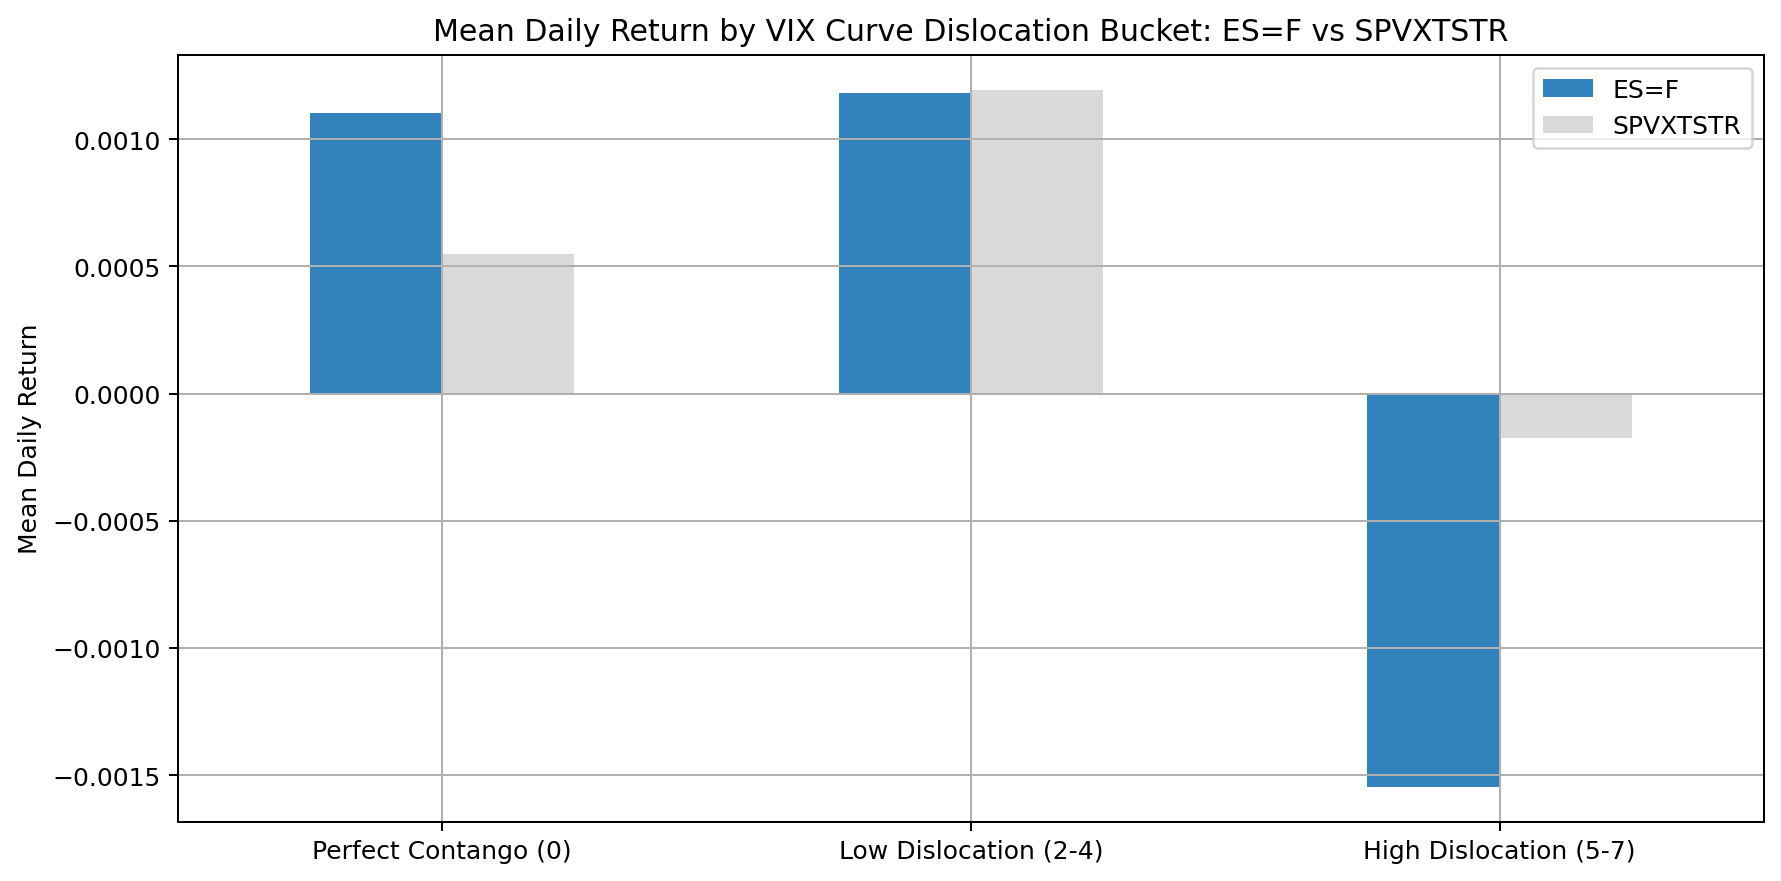

In [280]:
ax = same_day_two_asset_summary[[PRIMARY_EQUITY_PROXY, 'SPVXTSTR']].plot(
    kind='bar',
    grid=True,
    cmap='tab20c',
)
ax.set_title(f'Mean Daily Return by VIX Curve Dislocation Bucket: {PRIMARY_EQUITY_PROXY} vs SPVXTSTR')
ax.set_ylabel('Mean Daily Return')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()


Table 2 in the paper reports both the bucket counts and the average returns for ES and `SPVXTSTR`. The comparison table below lines up the paper's published values with the current replication output so we can see where the proxy data and signal implementation already agree, and where they still diverge.


In [281]:
paper_table_2 = pd.DataFrame(
    {
        'Count (paper)': [2761, 887, 1311],
        f'{PRIMARY_EQUITY_PROXY} avg return (paper %)': [0.108, 0.085, -0.134],
        'SPVXTSTR avg return (paper %)': [0.040, 0.131, 0.003],
    },
    index=DEFAULT_BUCKET_ORDER,
)

table_2_comparison = pd.DataFrame(index=DEFAULT_BUCKET_ORDER)
table_2_comparison['Count (paper)'] = paper_table_2['Count (paper)']
table_2_comparison['Count (replication)'] = same_day_two_asset_summary['count'].astype('Int64')
table_2_comparison[f'{PRIMARY_EQUITY_PROXY} avg return (paper %)'] = paper_table_2[f'{PRIMARY_EQUITY_PROXY} avg return (paper %)']
table_2_comparison[f'{PRIMARY_EQUITY_PROXY} avg return (repl %)'] = 100 * same_day_two_asset_summary[PRIMARY_EQUITY_PROXY]
table_2_comparison['SPVXTSTR avg return (paper %)'] = paper_table_2['SPVXTSTR avg return (paper %)']
table_2_comparison['SPVXTSTR avg return (repl %)'] = 100 * same_day_two_asset_summary['SPVXTSTR']
table_2_comparison


,Count (paper),Count (replication),ES=F avg return (paper %),ES=F avg return (repl %),SPVXTSTR avg return (paper %),SPVXTSTR avg return (repl %)
Perfect Contango (0),2761,2687,0.108,0.110234,0.040,0.054987
Low Dislocation (2-4),887,897,0.085,0.118292,0.131,0.119426
High Dislocation (5-7),1311,1284,-0.134,-0.154524,0.003,-0.017388


## 11. Appendix A: Shift The Returns To `t+1`

The paper explicitly points out that the same-day bucket test is descriptive, not tradable. Appendix A therefore asks a stricter question: if we classify the curve on day `t`, how do ES and `SPVXTSTR` behave on day `t+1`?

That shift is critical because it turns the dislocation count from a contemporaneous diagnostic into a signal that could actually drive an allocation decision on the next trading day.


In [282]:
next_day_two_asset_summary = summarize_bucket_returns(
    analysis_returns,
    daily_signal['dislocation_bucket_raw'],
    future_periods=1,
)

next_day_two_asset_summary


,count,ES=F,SPVXTSTR
dislocation_bucket,,,
Perfect Contango (0),2685,0.000271,-0.000070
Low Dislocation (2-4),898,0.000073,0.001261
High Dislocation (5-7),1284,0.000932,0.001098


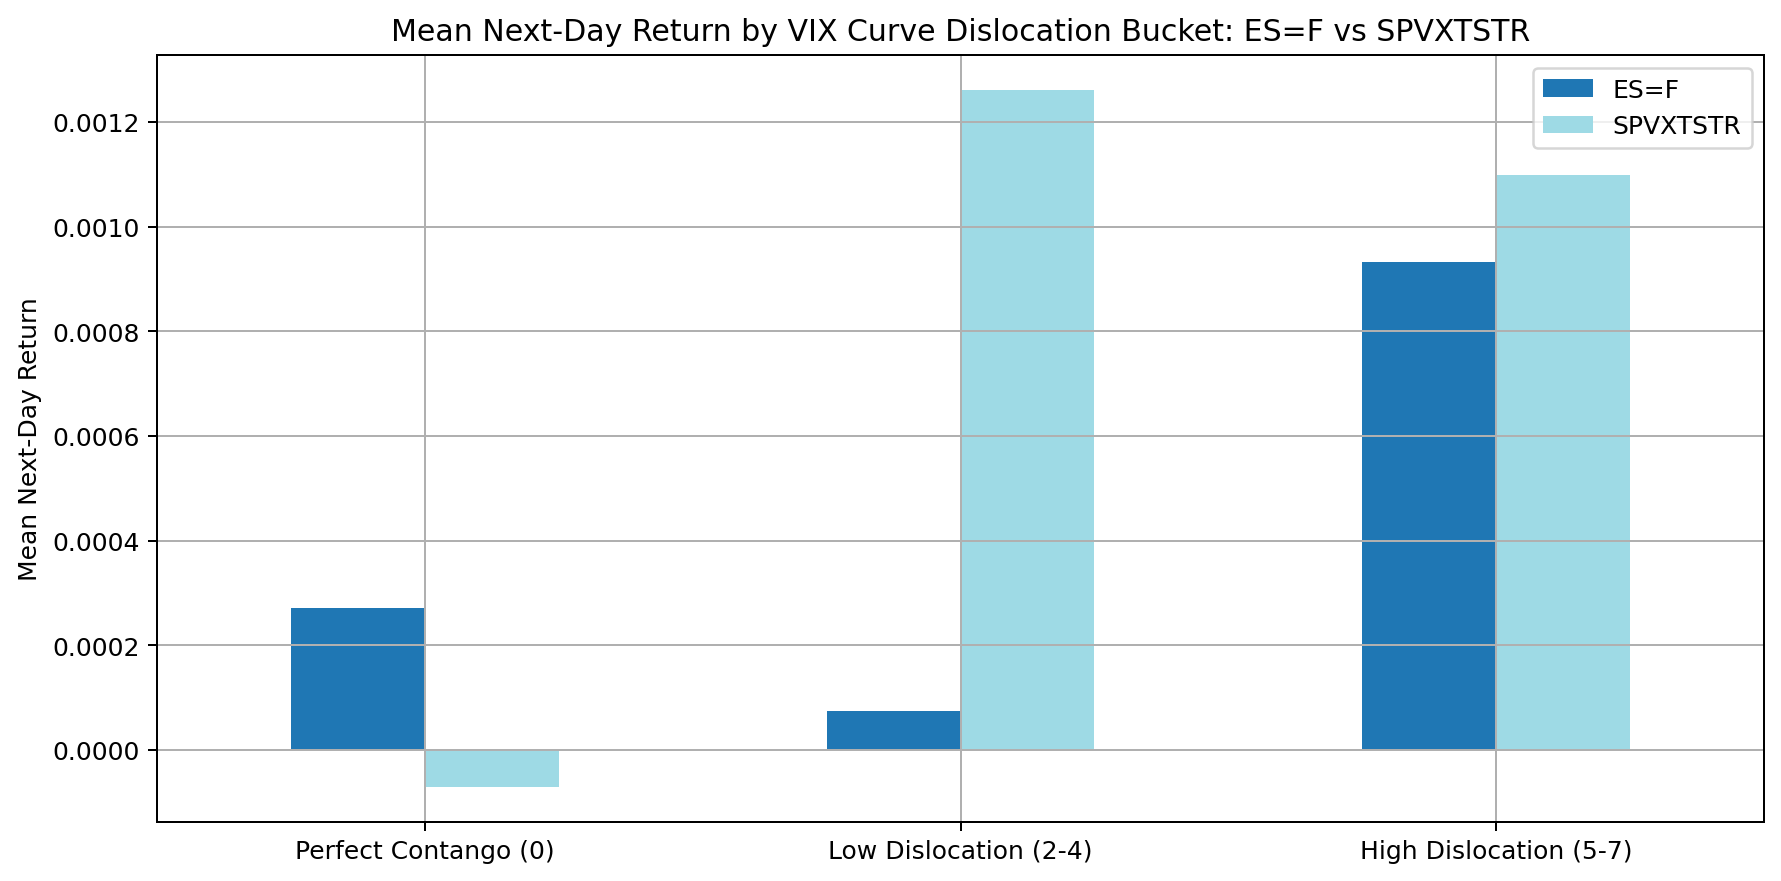

In [283]:
ax = next_day_two_asset_summary[[PRIMARY_EQUITY_PROXY, 'SPVXTSTR']].plot(
    kind='bar',
    grid=True,
    cmap='tab20',
)
ax.set_title(f'Mean Next-Day Return by VIX Curve Dislocation Bucket: {PRIMARY_EQUITY_PROXY} vs SPVXTSTR')
ax.set_ylabel('Mean Next-Day Return')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()


Appendix A then zooms into the high-dislocation bucket. The paper's interpretation is that `SPVXTSTR` has a tighter and more stable `t+1` return distribution than ES in those stressed regimes. The next cells reproduce that diagnostic in three ways: summary statistics, overlaid histograms, and a stem plot of outsized next-day equity moves.


In [284]:
high_dislocation_mask = daily_signal['dislocation_bucket_raw'].eq('High Dislocation (5-7)')
next_day_returns = analysis_returns.shift(-1)
high_bucket_next_day = next_day_returns.loc[high_dislocation_mask].dropna(how='any')
table_5_replication = summarize_conditional_returns(next_day_returns, high_dislocation_mask)

paper_table_5 = pd.DataFrame(
    {
        'Median (paper %)': [0.1569, 0.1362],
        'Mean (paper %)': [0.0729, 0.1288],
    },
    index=[PRIMARY_EQUITY_PROXY, 'SPVXTSTR'],
)

table_5_comparison = pd.DataFrame(index=[PRIMARY_EQUITY_PROXY, 'SPVXTSTR'])
table_5_comparison['Count (replication)'] = table_5_replication['count']
table_5_comparison['Median (paper %)'] = paper_table_5['Median (paper %)']
table_5_comparison['Median (repl %)'] = 100 * table_5_replication['median']
table_5_comparison['Mean (paper %)'] = paper_table_5['Mean (paper %)']
table_5_comparison['Mean (repl %)'] = 100 * table_5_replication['mean']
table_5_comparison


,Count (replication),Median (paper %),Median (repl %),Mean (paper %),Mean (repl %)
ES=F,1284,0.1569,0.196853,0.0729,0.093224
SPVXTSTR,1284,0.1362,0.123187,0.1288,0.109795


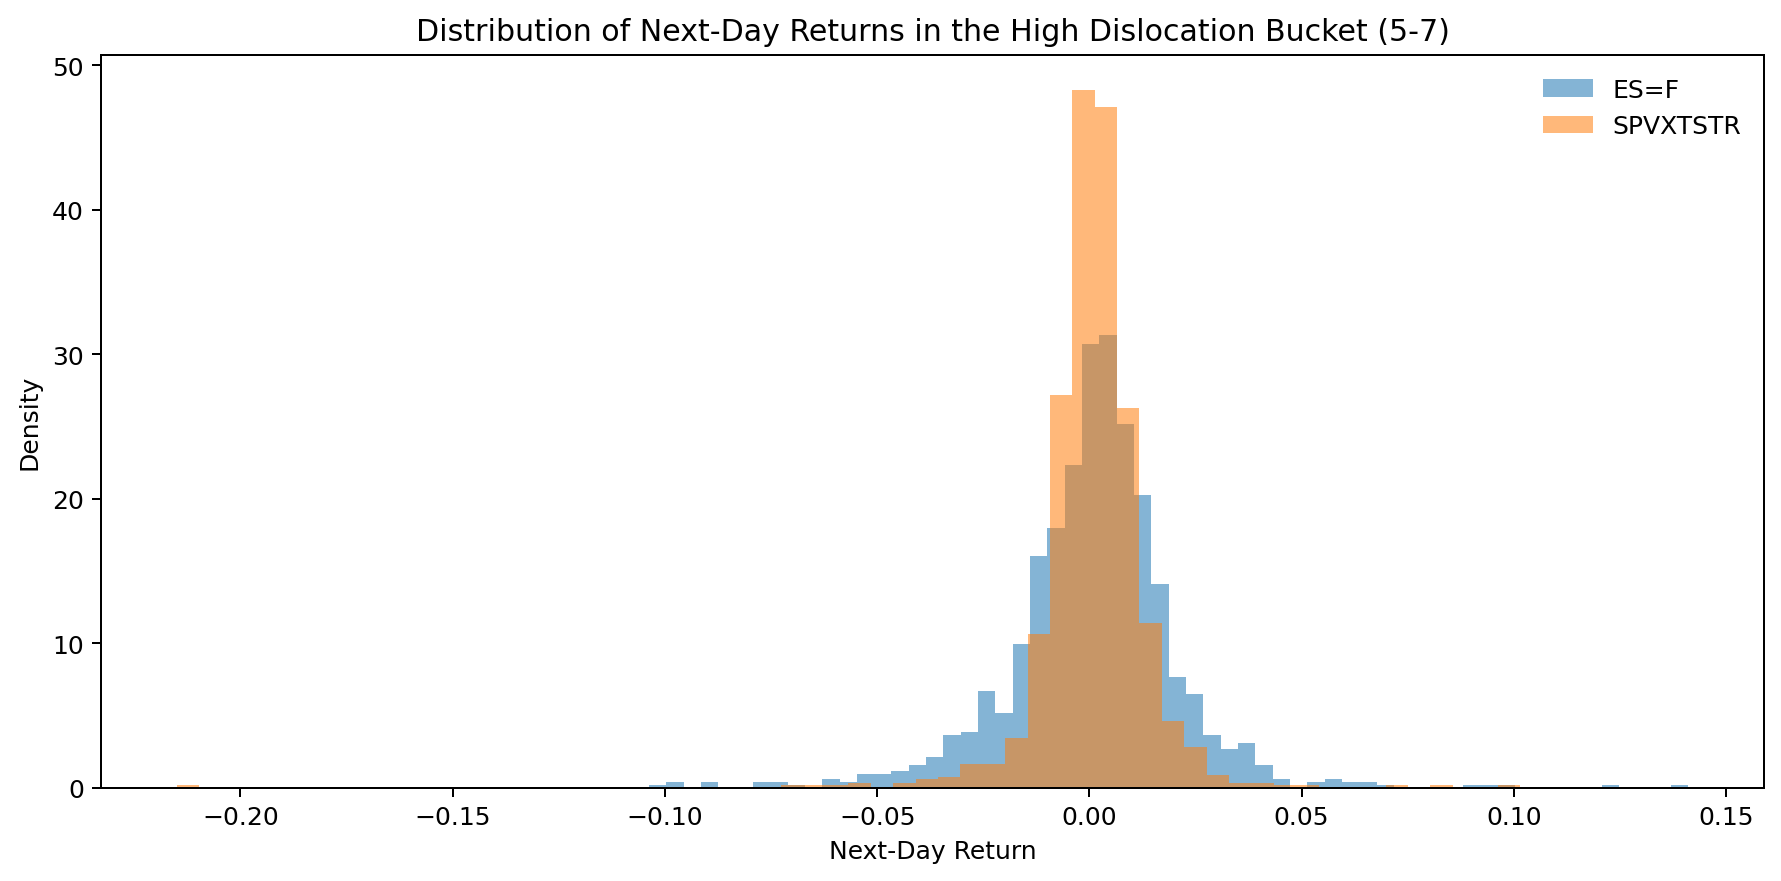

In [285]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    high_bucket_next_day[PRIMARY_EQUITY_PROXY],
    bins=60,
    density=True,
    alpha=0.55,
    label=PRIMARY_EQUITY_PROXY,
)
ax.hist(
    high_bucket_next_day['SPVXTSTR'],
    bins=60,
    density=True,
    alpha=0.55,
    label='SPVXTSTR',
)
ax.set_title('Distribution of Next-Day Returns in the High Dislocation Bucket (5-7)')
ax.set_xlabel('Next-Day Return')
ax.set_ylabel('Density')
ax.legend(frameon=False)
plt.tight_layout()


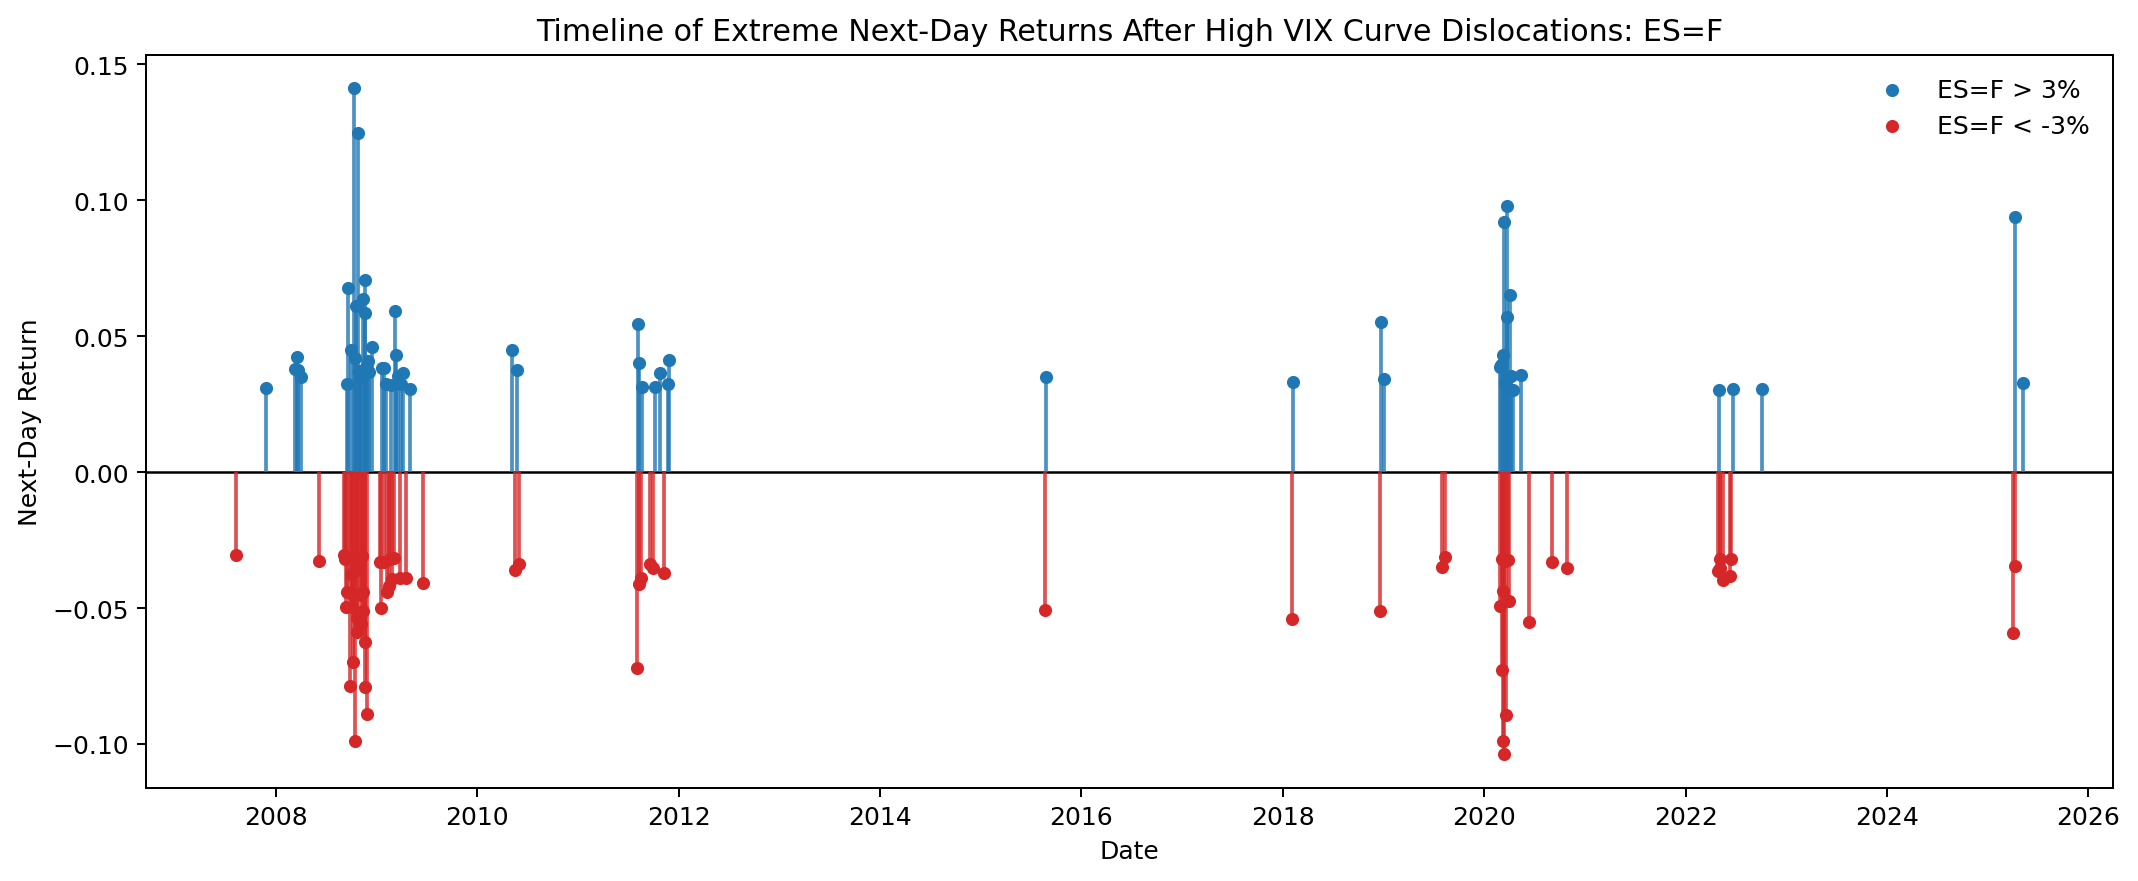

In [286]:
extreme_moves = extract_extreme_moves(
    next_day_returns[PRIMARY_EQUITY_PROXY],
    high_dislocation_mask,
    threshold=0.03,
)

positive_moves = extreme_moves[extreme_moves['direction'] == 'positive']
negative_moves = extreme_moves[extreme_moves['direction'] == 'negative']

fig, ax = plt.subplots(figsize=(12, 5))
ax.axhline(0.0, color='black', linewidth=1.0)

if not positive_moves.empty:
    ax.vlines(positive_moves.index, 0.0, positive_moves['return'], color='tab:blue', alpha=0.8)
    ax.scatter(positive_moves.index, positive_moves['return'], color='tab:blue', s=18, label=f'{PRIMARY_EQUITY_PROXY} > 3%')
if not negative_moves.empty:
    ax.vlines(negative_moves.index, 0.0, negative_moves['return'], color='tab:red', alpha=0.8)
    ax.scatter(negative_moves.index, negative_moves['return'], color='tab:red', s=18, label=f'{PRIMARY_EQUITY_PROXY} < -3%')

ax.set_title(f'Timeline of Extreme Next-Day Returns After High VIX Curve Dislocations: {PRIMARY_EQUITY_PROXY}')
ax.set_xlabel('Date')
ax.set_ylabel('Next-Day Return')
ax.legend(frameon=False)
plt.tight_layout()


## 12. From Signals To Program PnL

The earlier sections only ask whether the signal has descriptive power. The next step is to turn that signal into actual strategy returns. This is where we start reproducing the whitepaper's base-program figures.

Implementation choices in this notebook:
- The strategy default is `VX_PNL_MODE = 'generic_net_return'`, which preserves the generic return methodology and keeps the VA sleeve stable.
- `VX_PNL_PRICE_FIELD = 'settle_expiry_roll'` is still built and compared explicitly, so alternate expiry-roll PnL tests remain one variable change away.
- Using direct level-based returns from the expiry-roll ladder materially changes the VA curve, so that path is treated as an experiment rather than the default strategy engine.
- `SPVXTSTR` uses the normalized Bloomberg index returns.
- the equity leg still uses a Yahoo proxy, so we do not yet have the paper's exact ES roll schedule or explicit ES transaction costs.

That means the *shape* of the strategies is now investable and reproducible, while the last stage of paper matching will still come from tightening the ES implementation.


In [287]:
vx_returns_level = build_return_frame_from_levels(pnl_curve[['UX1', 'UX3']])
vx_returns_net = build_generic_return_frame(
    generic_frame,
    return_field='net_return',
    start=START,
    end=END,
    symbols=['UX1', 'UX3'],
)
vx_returns = vx_returns_net if VX_PNL_MODE == 'generic_net_return' else vx_returns_level

va_returns = (-0.5 * vx_returns['UX1'] + vx_returns['UX3']).rename('VA')
s0_weights = build_spvxtstr_program_weights(daily_signal, name='S0')
s0_turnover = build_turnover_series(s0_weights, weight_columns=['weight_es', 'weight_spvxtstr'])
daily_base_turnover = build_turnover_series(daily_base_weights, weight_columns=['weight_es', 'weight_ux1', 'weight_ux3'])
weekly_base_turnover = build_turnover_series(weekly_base_weights, weight_columns=['weight_es', 'weight_ux1', 'weight_ux3'])
daily_refined_turnover = build_turnover_series(daily_refined_weights, weight_columns=['weight_es', 'weight_ux1', 'weight_ux3'])
weekly_refined_turnover = build_turnover_series(weekly_refined_weights, weight_columns=['weight_es', 'weight_ux1', 'weight_ux3'])
weekly_long_only_turnover = build_turnover_series(weekly_long_only_weights, weight_columns=['weight_es', 'weight_ux1', 'weight_ux3'])

s0_asset_returns = pd.concat(
    [
        proxy_returns[[PRIMARY_EQUITY_PROXY]].rename(columns={PRIMARY_EQUITY_PROXY: 'ES'}),
        spvxtstr[['spvxtstr_return']].rename(columns={'spvxtstr_return': 'SPVXTSTR'}),
    ],
    axis=1,
    sort=False,
)
s1_asset_returns = pd.concat(
    [
        proxy_returns[[PRIMARY_EQUITY_PROXY]].rename(columns={PRIMARY_EQUITY_PROXY: 'ES'}),
        vx_returns,
    ],
    axis=1,
    sort=False,
)

s0_returns = combine_weighted_returns(
    s0_asset_returns,
    s0_weights,
    asset_weight_map={'ES': 'weight_es', 'SPVXTSTR': 'weight_spvxtstr'},
    name='S0',
)
cuttlefish_returns = combine_weighted_returns(
    s1_asset_returns,
    daily_base_weights,
    asset_weight_map={'ES': 'weight_es', 'UX1': 'weight_ux1', 'UX3': 'weight_ux3'},
    name='Cuttlefish',
)
squid_returns = combine_weighted_returns(
    s1_asset_returns,
    weekly_base_weights,
    asset_weight_map={'ES': 'weight_es', 'UX1': 'weight_ux1', 'UX3': 'weight_ux3'},
    name='Squid',
)
giant_returns = combine_weighted_returns(
    s1_asset_returns,
    weekly_refined_weights,
    asset_weight_map={'ES': 'weight_es', 'UX1': 'weight_ux1', 'UX3': 'weight_ux3'},
    name='Giant Squid',
)
jumbo_returns = combine_weighted_returns(
    s1_asset_returns,
    weekly_long_only_weights,
    asset_weight_map={'ES': 'weight_es', 'UX1': 'weight_ux1', 'UX3': 'weight_ux3'},
    name='Jumbo Squid',
)
colossal_returns = combine_weighted_returns(
    s1_asset_returns,
    daily_refined_weights,
    asset_weight_map={'ES': 'weight_es', 'UX1': 'weight_ux1', 'UX3': 'weight_ux3'},
    name='Colossal Squid',
)

growth_curves = pd.DataFrame(
    {
        PRIMARY_EQUITY_PROXY: build_growth_index(proxy_returns[PRIMARY_EQUITY_PROXY]),
        'SPVXTSTR': build_growth_index(spvxtstr['spvxtstr_return']),
        'VA': build_growth_index(va_returns),
        'S0': build_growth_index(s0_returns),
        'Cuttlefish': build_growth_index(cuttlefish_returns),
        'Squid': build_growth_index(squid_returns),
        'Giant Squid': build_growth_index(giant_returns),
        'Jumbo Squid': build_growth_index(jumbo_returns),
        'Colossal Squid': build_growth_index(colossal_returns),
    }
)
drawdown_curves = growth_curves.apply(build_drawdown_series)

strategy_start_summary = pd.DataFrame(
    {
        'series': growth_curves.columns,
        'first_valid_date': [growth_curves[column].dropna().index.min() for column in growth_curves.columns],
        'valid_observations': [int(growth_curves[column].notna().sum()) for column in growth_curves.columns],
    }
)
strategy_start_summary


,series,first_valid_date,valid_observations
0,ES=F,2006-04-06,4969
1,SPVXTSTR,2006-04-05,4963
2,VA,2006-05-15,4891
3,S0,2006-04-06,4962
4,Cuttlefish,2006-05-15,4891
5,Squid,2006-05-15,4891
6,Giant Squid,2006-05-15,4891
7,Jumbo Squid,2006-05-15,4891
8,Colossal Squid,2006-05-15,4891


### VX PnL Method Comparison

Because the VX leg is now configurable, this cell compares the current test setup against the previous notebook behavior. The first series computes VA returns directly from the `VX_PNL_PRICE_FIELD` levels. The second series reuses the cleaned generic `net_return` field, which already includes the roll-aware transaction-cost treatment from the generic builder.

This lets you see exactly how much your test change is moving the volatility sleeve before it flows into the higher-level strategy curves.


,active_vx_pnl_mode,vx_pnl_price_field
0,generic_net_return,settle_expiry_roll


,VA (from VX_PNL_PRICE_FIELD),VA (generic net_return)
Annualized Returns (%),-11.12,6.22
Annualized Volatility (%),25.77,15.77
Max Drawdown (%),93.52,72.77
Sharpe Ratio,-0.43,0.39
Sortino Ratio,-0.58,0.58


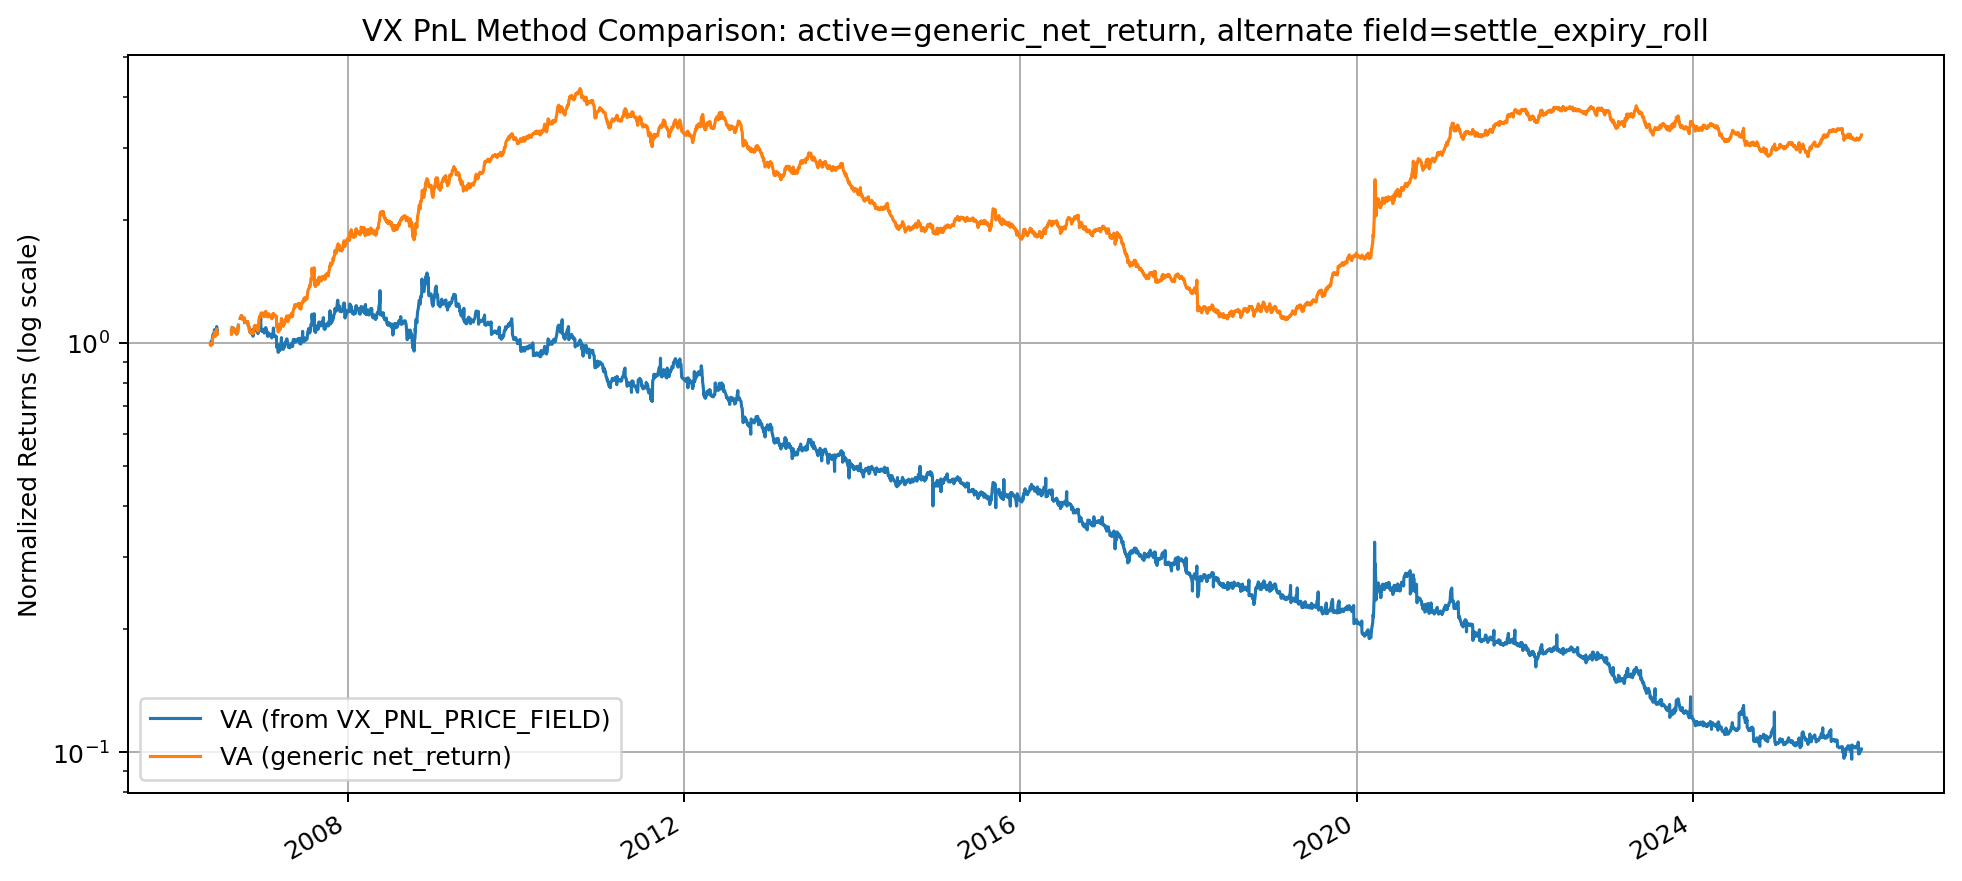

In [288]:
va_returns_net = (-0.5 * vx_returns_net['UX1'] + vx_returns_net['UX3']).rename('VA (generic net_return)')
va_returns_levels = (-0.5 * vx_returns_level['UX1'] + vx_returns_level['UX3']).rename('VA (from VX_PNL_PRICE_FIELD)')

vx_pnl_comparison = pd.DataFrame(
    {
        'VA (from VX_PNL_PRICE_FIELD)': summarize_performance(va_returns_levels),
        'VA (generic net_return)': summarize_performance(va_returns_net),
    }
)

vx_pnl_display = pd.DataFrame(
    {
        'VA (from VX_PNL_PRICE_FIELD)': [
            100 * vx_pnl_comparison.loc['annualized_return', 'VA (from VX_PNL_PRICE_FIELD)'],
            100 * vx_pnl_comparison.loc['annualized_volatility', 'VA (from VX_PNL_PRICE_FIELD)'],
            100 * abs(vx_pnl_comparison.loc['max_drawdown', 'VA (from VX_PNL_PRICE_FIELD)']),
            vx_pnl_comparison.loc['sharpe_ratio', 'VA (from VX_PNL_PRICE_FIELD)'],
            vx_pnl_comparison.loc['sortino_ratio', 'VA (from VX_PNL_PRICE_FIELD)'],
        ],
        'VA (generic net_return)': [
            100 * vx_pnl_comparison.loc['annualized_return', 'VA (generic net_return)'],
            100 * vx_pnl_comparison.loc['annualized_volatility', 'VA (generic net_return)'],
            100 * abs(vx_pnl_comparison.loc['max_drawdown', 'VA (generic net_return)']),
            vx_pnl_comparison.loc['sharpe_ratio', 'VA (generic net_return)'],
            vx_pnl_comparison.loc['sortino_ratio', 'VA (generic net_return)'],
        ],
    },
    index=[
        'Annualized Returns (%)',
        'Annualized Volatility (%)',
        'Max Drawdown (%)',
        'Sharpe Ratio',
        'Sortino Ratio',
    ],
)

vx_pnl_growth = pd.DataFrame(
    {
        'VA (from VX_PNL_PRICE_FIELD)': build_growth_index(va_returns_levels),
        'VA (generic net_return)': build_growth_index(va_returns_net),
    }
)

display(pd.DataFrame({'active_vx_pnl_mode': [VX_PNL_MODE], 'vx_pnl_price_field': [VX_PNL_PRICE_FIELD]}))
display(vx_pnl_display.round(2))
ax = vx_pnl_growth.plot(logy=True, figsize=(11, 5), linewidth=1.25, grid=True)
ax.set_title(f'VX PnL Method Comparison: active={VX_PNL_MODE}, alternate field={VX_PNL_PRICE_FIELD}')
ax.set_ylabel('Normalized Returns (log scale)')
ax.set_xlabel('')
plt.tight_layout()


### Figure 5 Style: `S0` Versus Its Two Components

`S0` is the paper's first dynamic allocation: equity on one side, `SPVXTSTR` on the other, with the dislocation count determining how much of the portfolio sits in each. The plot below mirrors that structure with a log growth chart on the left axis and the raw daily dislocation count on the right axis.


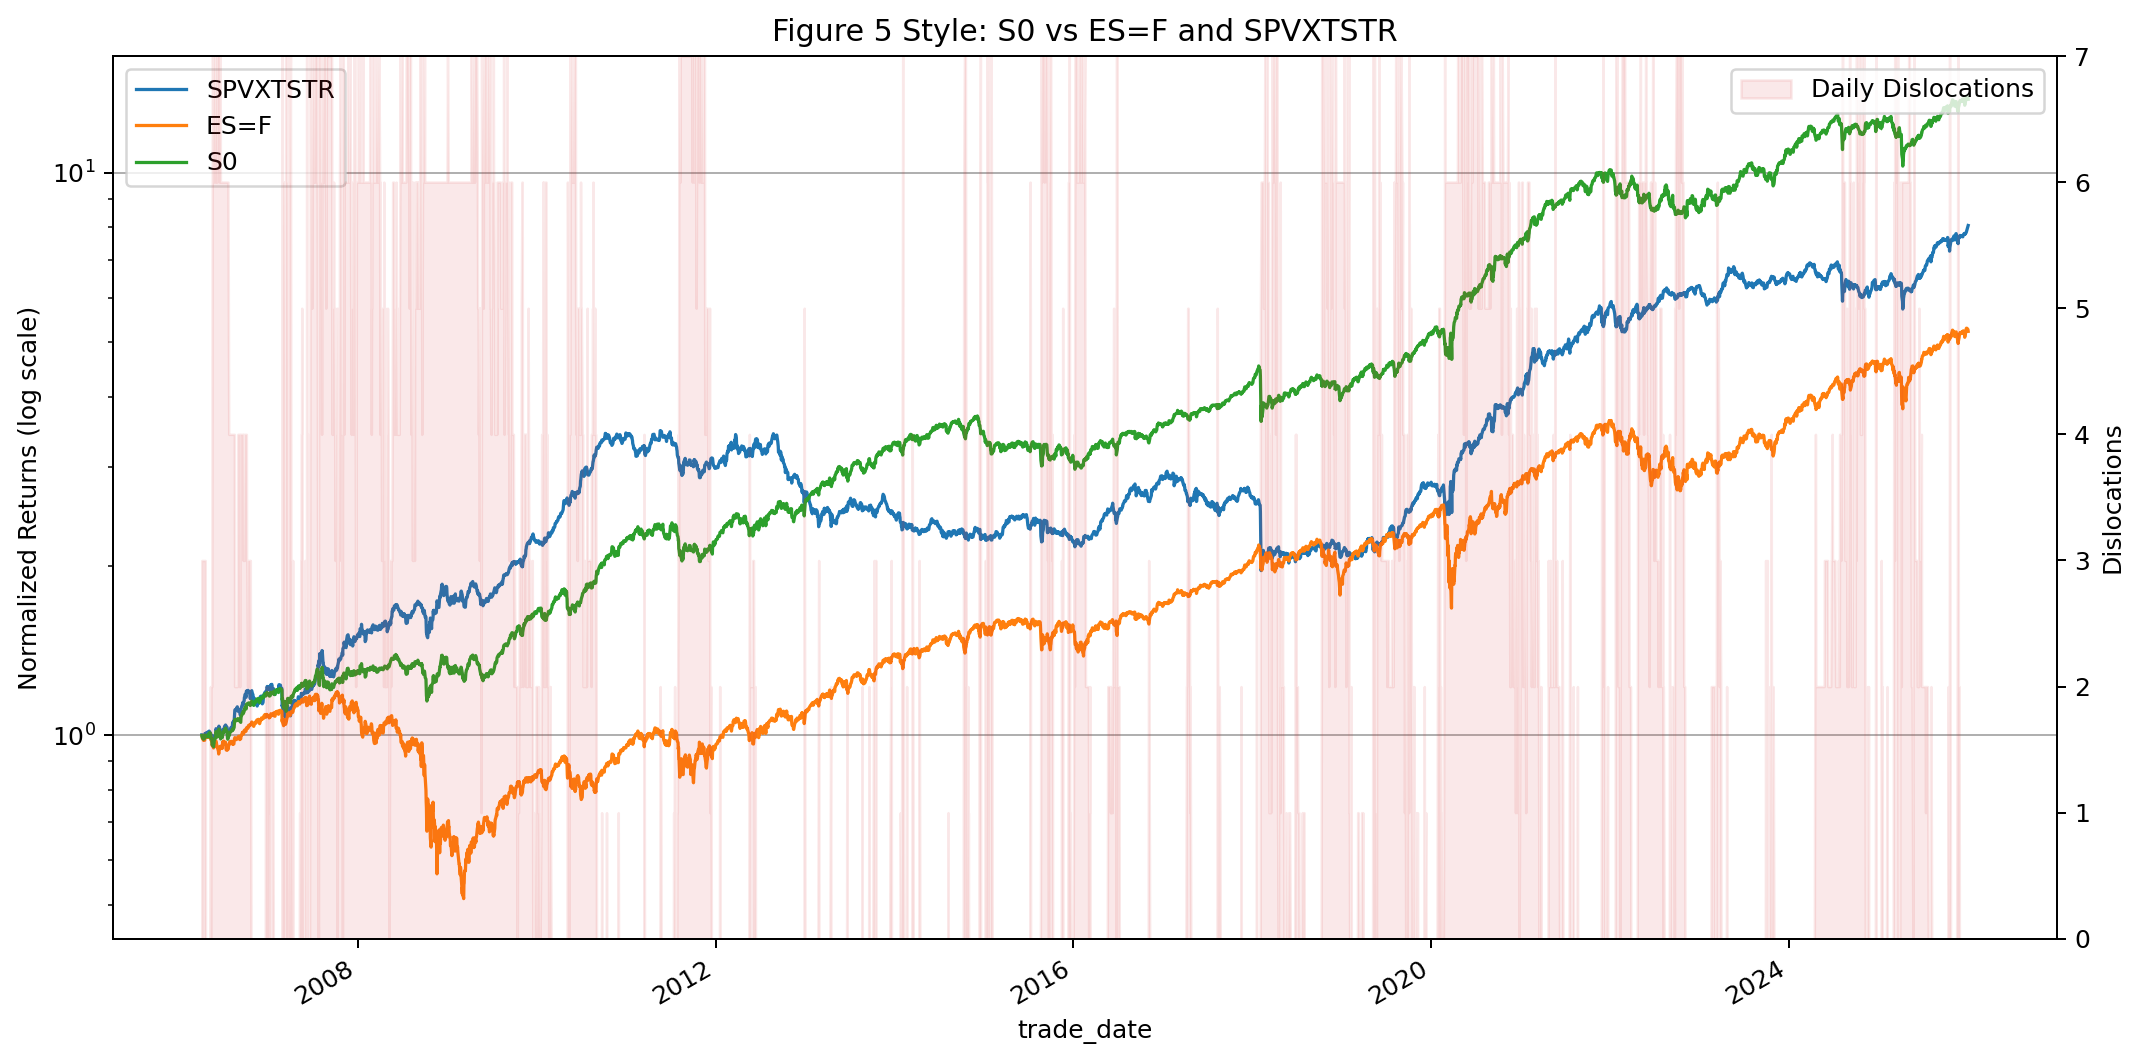

In [289]:
fig, ax1 = plt.subplots(figsize=(12, 6))
growth_curves[['SPVXTSTR', PRIMARY_EQUITY_PROXY, 'S0']].plot(ax=ax1, logy=True, linewidth=1.3)
ax1.set_title(f'Figure 5 Style: S0 vs {PRIMARY_EQUITY_PROXY} and SPVXTSTR')
ax1.set_ylabel('Normalized Returns (log scale)')


ax2 = ax1.twinx()
ax2.fill_between(
    daily_signal.index,
    0,
    daily_signal['dislocation_count_raw'].astype(float),
    color='tab:red',
    alpha=0.10,
    label='Daily Dislocations',
)
ax2.set_ylabel('Dislocations')
ax2.set_ylim(0, 7)

ax1.grid(True, axis='y')
ax1.set_axisbelow(True)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()


### Figure 6 Style: `SPVXTSTR` Versus The Simplified Volatility Allocation

The whitepaper then replaces the constant-maturity volatility benchmark with a simpler tradeable approximation, `VA = -0.5 * UX1 + UX3`. This plot isolates that substitution: it shows whether the simplified allocation still behaves like a useful crisis-sensitive volatility sleeve even though it is structurally different from `SPVXTSTR`.


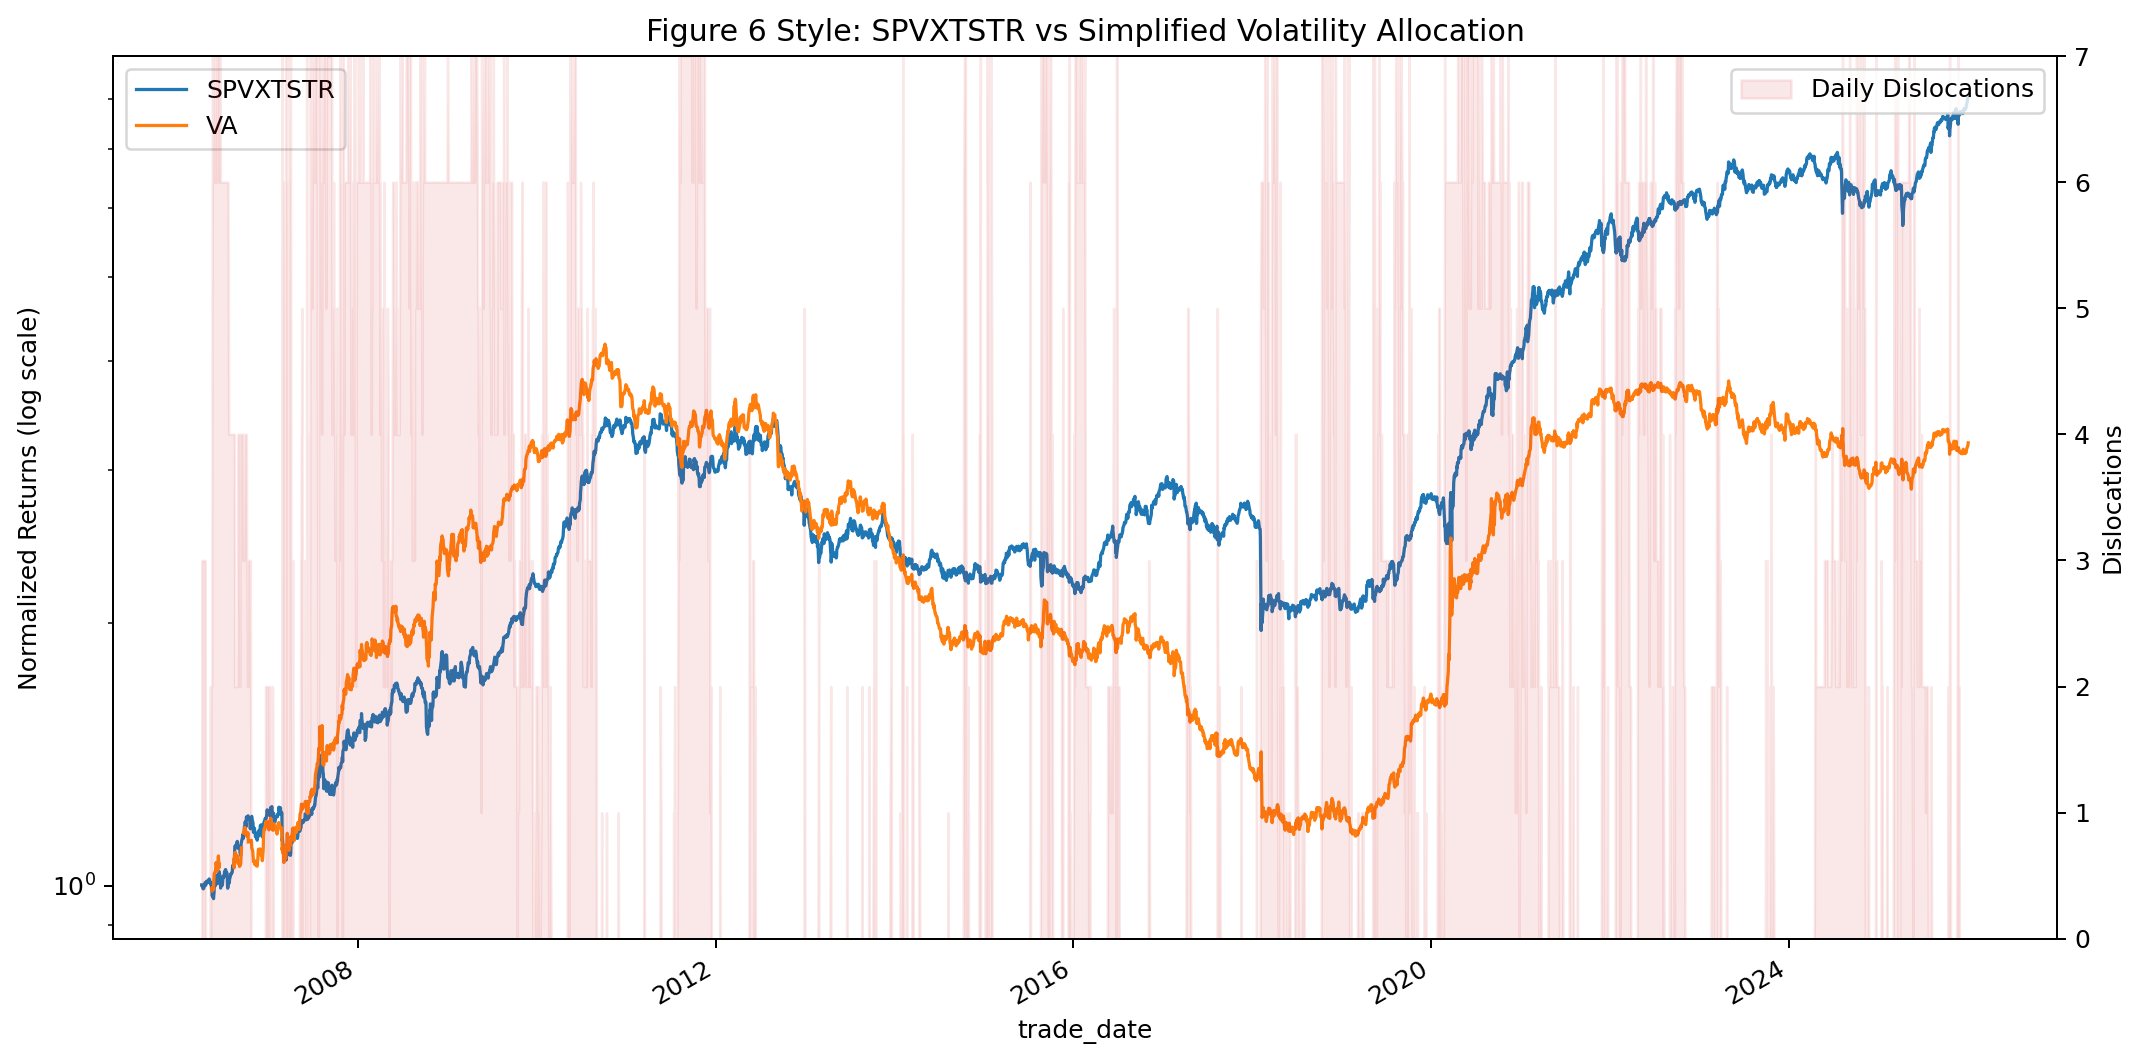

In [290]:
fig, ax1 = plt.subplots(figsize=(12, 6))
growth_curves[['SPVXTSTR', 'VA']].plot(ax=ax1, logy=True, linewidth=1.3)
ax1.set_title('Figure 6 Style: SPVXTSTR vs Simplified Volatility Allocation')
ax1.set_ylabel('Normalized Returns (log scale)')

ax2 = ax1.twinx()
ax2.fill_between(
    daily_signal.index,
    0,
    daily_signal['dislocation_count_raw'].astype(float),
    color='tab:red',
    alpha=0.10,
    label='Daily Dislocations',
)
ax2.set_ylabel('Dislocations')
ax2.set_ylim(0, 7)

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()


### Figure 7 Style: Weekly Squid Versus The Daily Base Model

Finally, the paper shifts from a daily to a weekly signal by using the previous week's average dislocation count. The resulting `Squid` program should trade less often than the daily `S1 / Cuttlefish` signal while still preserving the basic dynamic-allocation idea.

Because `UX3` is not available for the entire sample right from the first date, the `S1 / Cuttlefish` and `Squid` curves start later than `S0`. That is expected and reflects the actual generic ladder coverage rather than a notebook bug.


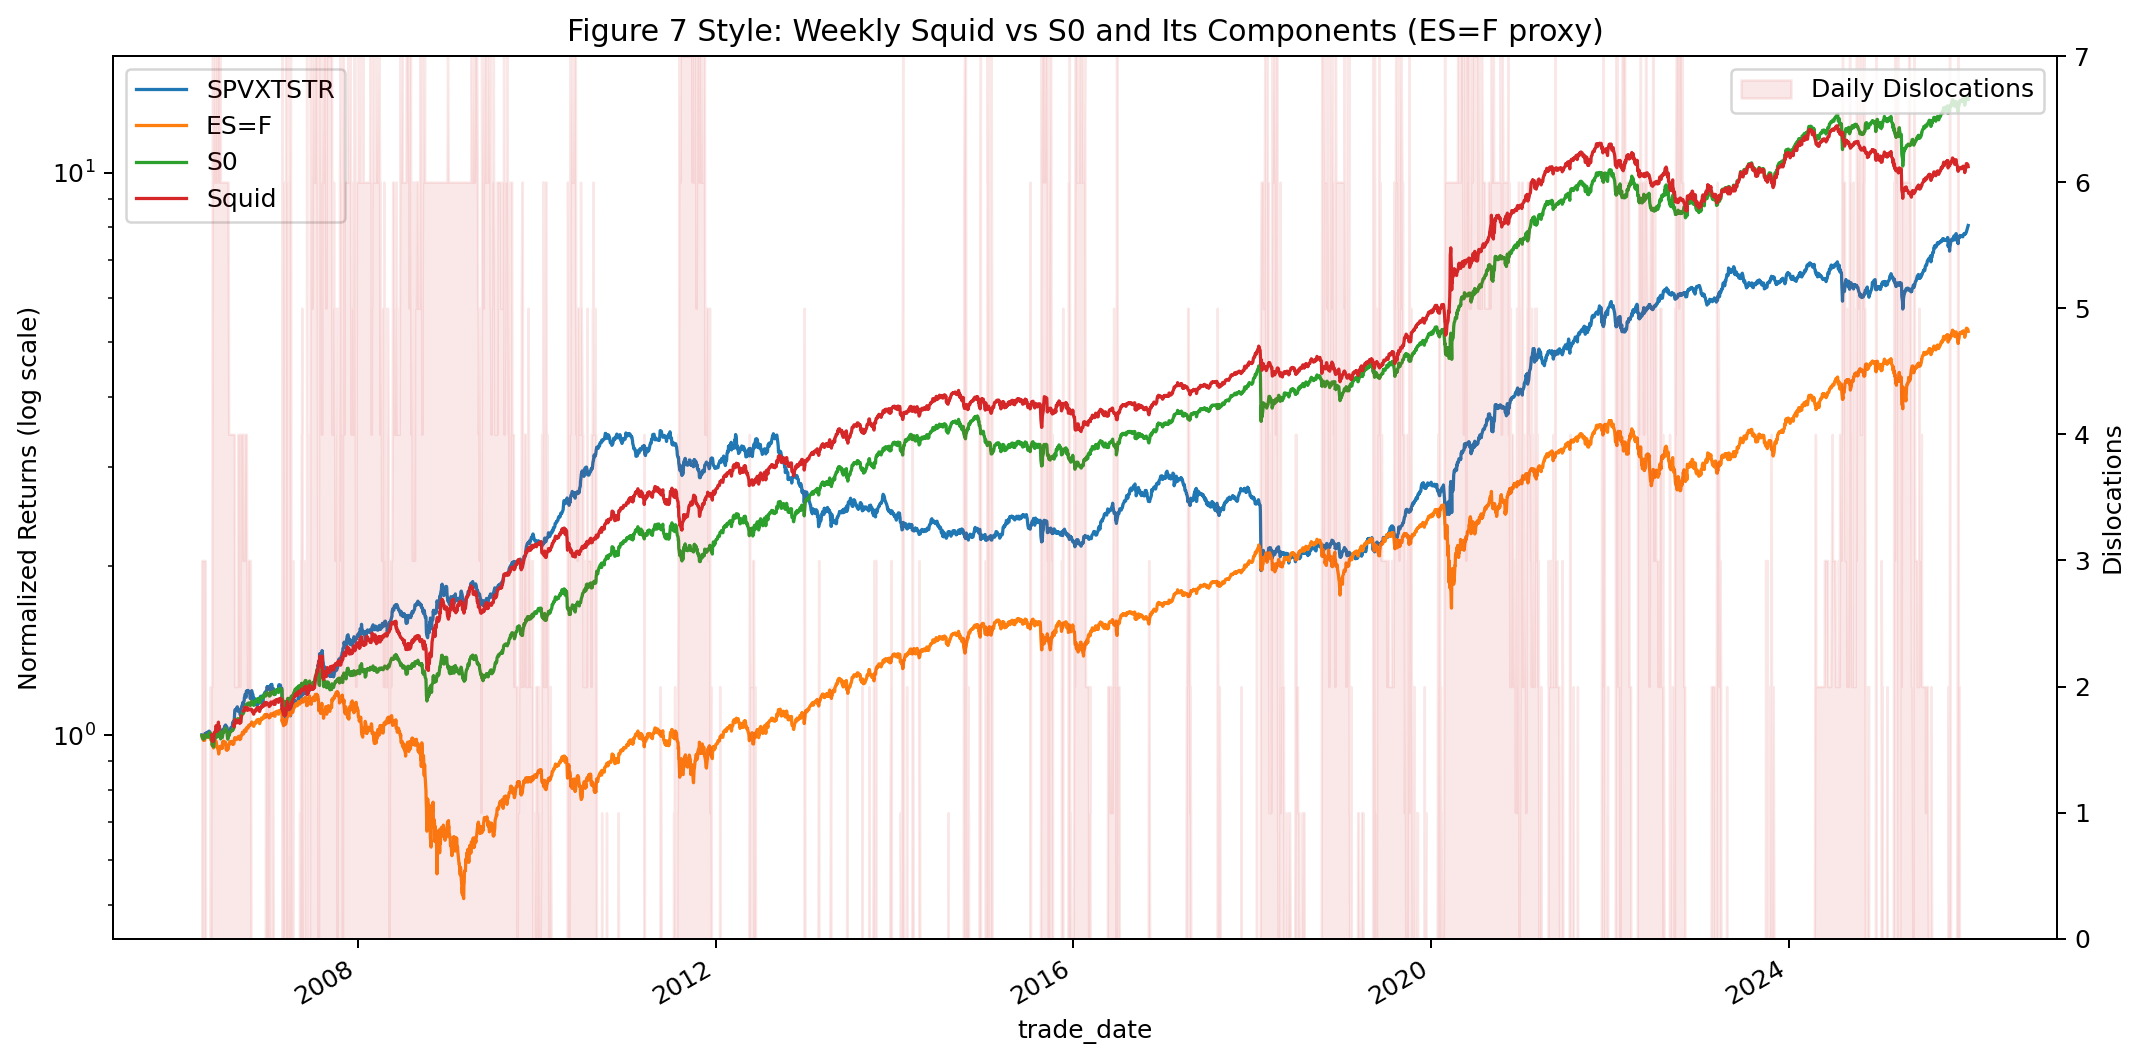

In [291]:
fig, ax1 = plt.subplots(figsize=(12, 6))
growth_curves[['SPVXTSTR', PRIMARY_EQUITY_PROXY, 'S0', 'Squid']].plot(ax=ax1, logy=True, linewidth=1.3)
ax1.set_title(f'Figure 7 Style: Weekly Squid vs S0 and Its Components ({PRIMARY_EQUITY_PROXY} proxy)')
ax1.set_ylabel('Normalized Returns (log scale)')

ax2 = ax1.twinx()
ax2.fill_between(
    daily_signal.index,
    0,
    daily_signal['dislocation_count_raw'].astype(float),
    color='tab:red',
    alpha=0.10,
    label='Daily Dislocations',
)
ax2.set_ylabel('Dislocations')
ax2.set_ylim(0, 7)

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()


## 13. Table 3 Style: Base-Program Performance

The paper reports summary statistics for the S&P 500, the weekly `Squid` program, and the daily `Cuttlefish` program. We compute the same family of metrics here on the common overlap of the three series so the comparison is period-consistent.

Turnover here is an approximation of one-way turnover from changes in target component weights, not a full futures execution model. That is sufficient for ranking the daily versus weekly variants, even if the exact percentage will still move once the ES leg is modeled more strictly.


In [292]:
base_common_returns = pd.concat(
    [
        proxy_returns[[PRIMARY_EQUITY_PROXY]],
        cuttlefish_returns.rename('Cuttlefish'),
        squid_returns.rename('Squid'),
    ],
    axis=1,
    sort=False,
).dropna(how='any')

table_3_raw = pd.DataFrame(
    {
        PRIMARY_EQUITY_PROXY: summarize_performance(base_common_returns[PRIMARY_EQUITY_PROXY]),
        'Squid': summarize_performance(
            base_common_returns['Squid'],
            turnover=weekly_base_turnover.reindex(base_common_returns.index),
        ),
        'Cuttlefish': summarize_performance(
            base_common_returns['Cuttlefish'],
            turnover=daily_base_turnover.reindex(base_common_returns.index),
        ),
    }
)

table_3_display = pd.DataFrame(
    {
        PRIMARY_EQUITY_PROXY: [
            100 * table_3_raw.loc['annualized_return', PRIMARY_EQUITY_PROXY],
            100 * table_3_raw.loc['annualized_volatility', PRIMARY_EQUITY_PROXY],
            100 * abs(table_3_raw.loc['max_drawdown', PRIMARY_EQUITY_PROXY]),
            table_3_raw.loc['sharpe_ratio', PRIMARY_EQUITY_PROXY],
            table_3_raw.loc['sortino_ratio', PRIMARY_EQUITY_PROXY],
            pd.NA,
        ],
        'Weekly Program: Squid': [
            100 * table_3_raw.loc['annualized_return', 'Squid'],
            100 * table_3_raw.loc['annualized_volatility', 'Squid'],
            100 * abs(table_3_raw.loc['max_drawdown', 'Squid']),
            table_3_raw.loc['sharpe_ratio', 'Squid'],
            table_3_raw.loc['sortino_ratio', 'Squid'],
            100 * table_3_raw.loc['turnover', 'Squid'],
        ],
        'Daily Program: Cuttlefish': [
            100 * table_3_raw.loc['annualized_return', 'Cuttlefish'],
            100 * table_3_raw.loc['annualized_volatility', 'Cuttlefish'],
            100 * abs(table_3_raw.loc['max_drawdown', 'Cuttlefish']),
            table_3_raw.loc['sharpe_ratio', 'Cuttlefish'],
            table_3_raw.loc['sortino_ratio', 'Cuttlefish'],
            100 * table_3_raw.loc['turnover', 'Cuttlefish'],
        ],
    },
    index=[
        'Annualized Returns (%)',
        'Annualized Volatility (%)',
        'Max Drawdown (%)',
        'Sharpe Ratio',
        'Sortino Ratio',
        'Turnover (%)',
    ],
)
table_3_display.round(2)


,ES=F,Weekly Program: Squid,Daily Program: Cuttlefish
Annualized Returns (%),8.839071,12.74,13.80
Annualized Volatility (%),19.839166,13.54,13.90
Max Drawdown (%),57.113402,25.67,23.55
Sharpe Ratio,0.445536,0.94,0.99
Sortino Ratio,0.624084,1.34,1.44
Turnover (%),<NA>,2.32,7.83


## 14. Refined Programs

The paper then adds the two regime refinements already introduced earlier in the notebook: a slope filter and a spot-VIX filter. These create three new strategy variants:
- `Giant Squid`: weekly, long/short ES allowed
- `Jumbo Squid`: weekly, long-only ES
- `Colossal Squid`: daily, long/short ES allowed

The weights for these programs were already built earlier. The next cells convert those weights into return streams, growth curves, drawdowns, and performance tables.


In [293]:
weekly_program_growth = growth_curves[[PRIMARY_EQUITY_PROXY, 'Squid', 'Giant Squid', 'Jumbo Squid']]
weekly_program_drawdowns = drawdown_curves[[PRIMARY_EQUITY_PROXY, 'Squid', 'Giant Squid', 'Jumbo Squid']]
daily_program_growth = growth_curves[[PRIMARY_EQUITY_PROXY, 'Cuttlefish', 'Colossal Squid']]
daily_program_drawdowns = drawdown_curves[[PRIMARY_EQUITY_PROXY, 'Cuttlefish', 'Colossal Squid']]

refined_common_returns = pd.concat(
    [
        proxy_returns[[PRIMARY_EQUITY_PROXY]],
        giant_returns.rename('Giant Squid'),
        jumbo_returns.rename('Jumbo Squid'),
        colossal_returns.rename('Colossal Squid'),
    ],
    axis=1,
    sort=False,
).dropna(how='any')

refined_common_returns.head()


,ES=F,Giant Squid,Jumbo Squid,Colossal Squid
trade_date,,,,
2006-05-15,0.002318,0.001169,0.001169,-0.000554
2006-05-16,-0.001734,-0.001508,-0.001508,-0.001169
2006-05-17,-0.020077,-0.018589,-0.018589,-0.016356
2006-05-18,-0.004728,-0.004064,-0.004064,-0.000575
2006-05-19,0.006136,0.006196,0.006196,0.006399


### Figure 9 Style: Weekly Programs Log Growth

This plot compares the weekly base model (`Squid`) to the two refined weekly variants. The paper's central question here is whether the slope and spot-VIX filters improve the base weekly program without losing its crisis response.


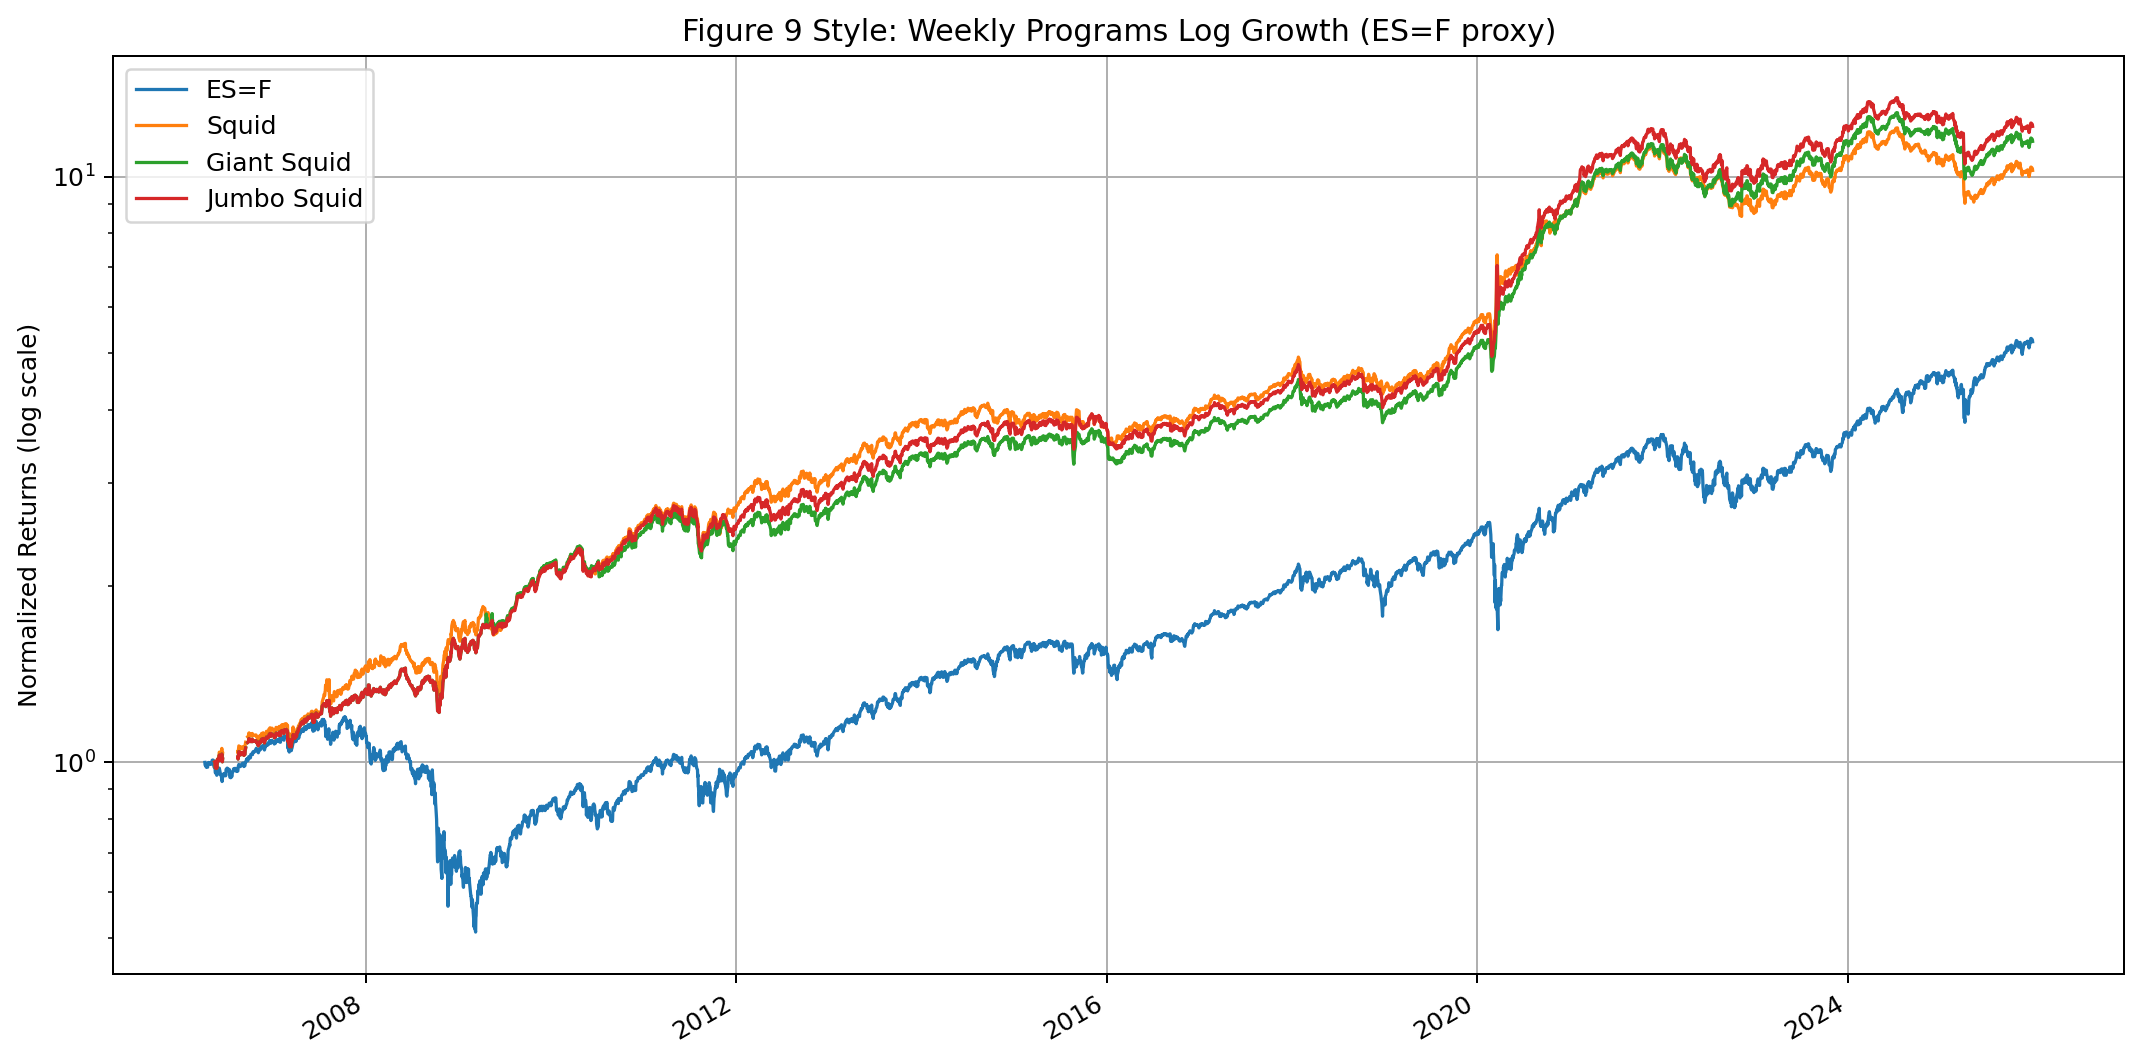

In [294]:
ax = weekly_program_growth.plot(logy=True, figsize=(12, 6), linewidth=1.3, grid=True)
ax.set_title(f'Figure 9 Style: Weekly Programs Log Growth ({PRIMARY_EQUITY_PROXY} proxy)')
ax.set_ylabel('Normalized Returns (log scale)')
ax.set_xlabel('')
plt.tight_layout()


### Figure 10 Style: Weekly Programs Underwater

The underwater plot complements the log-growth chart by focusing on drawdown depth and persistence. This is often the cleanest way to see whether the refined weekly models are actually delivering the drawdown control the paper is aiming for.


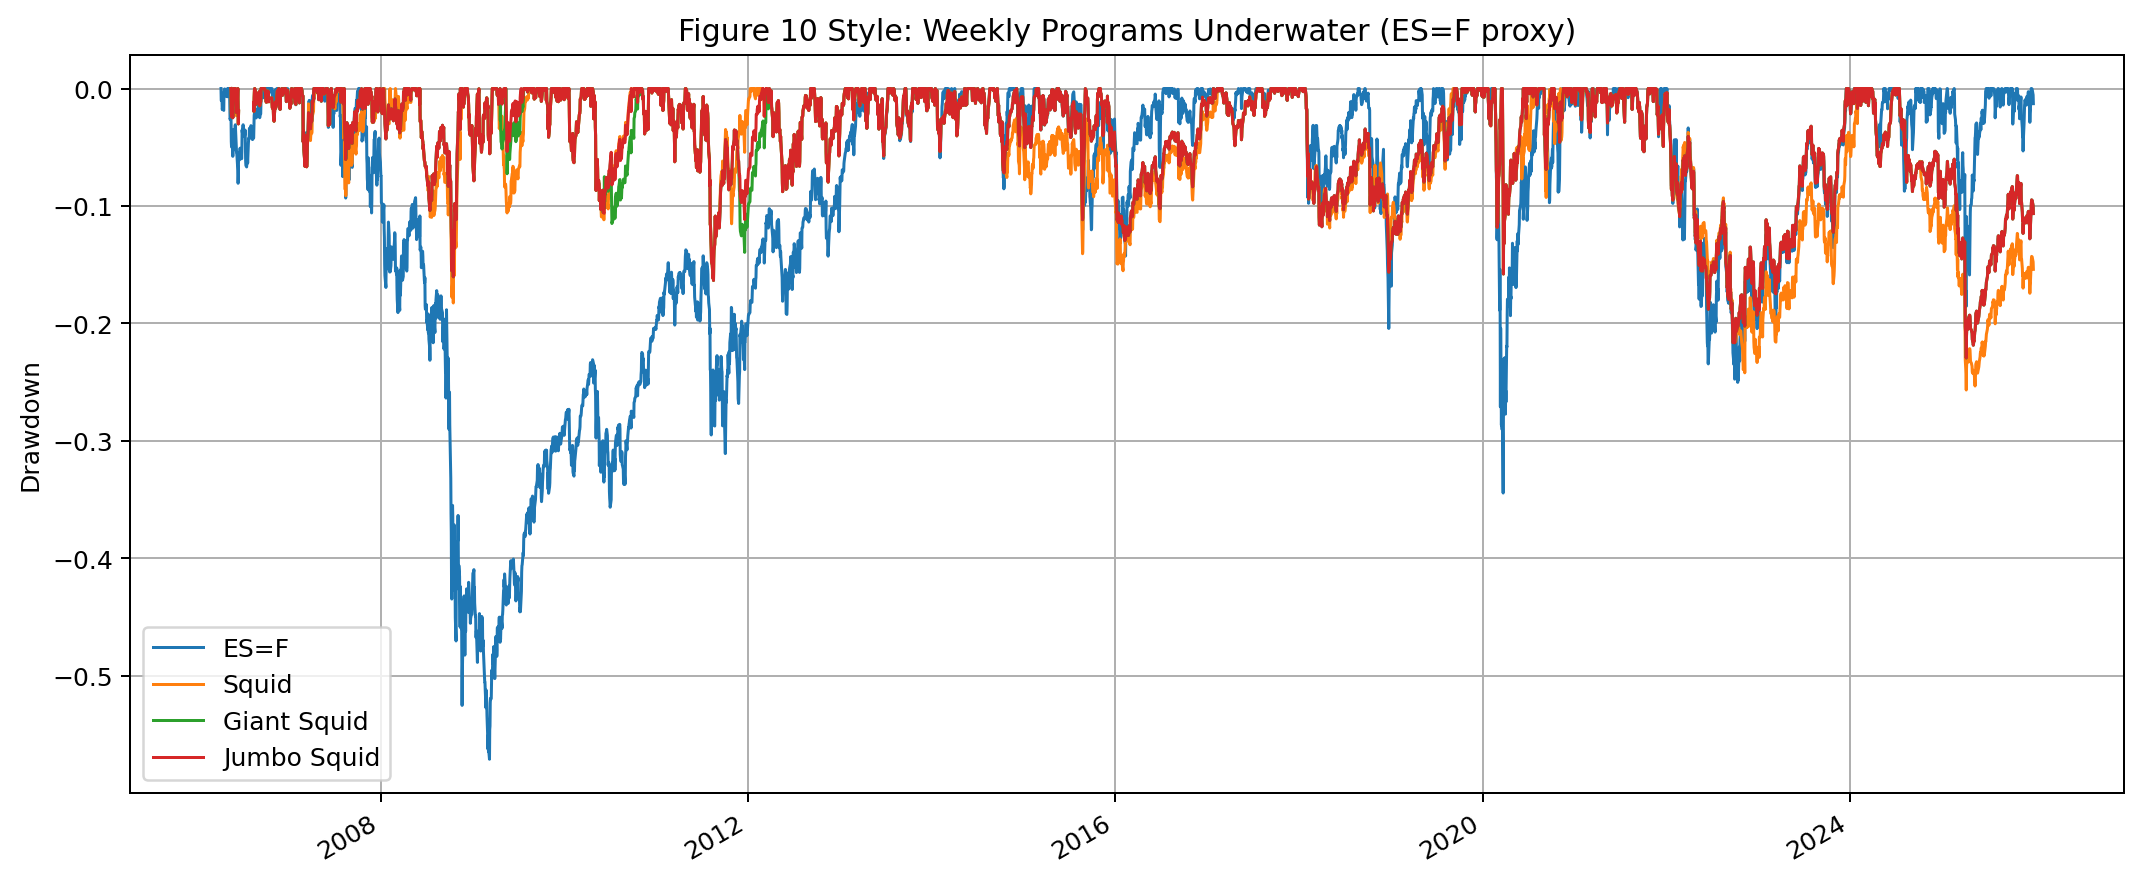

In [295]:
ax = weekly_program_drawdowns.plot(figsize=(12, 5), linewidth=1.2, grid=True)
ax.set_title(f'Figure 10 Style: Weekly Programs Underwater ({PRIMARY_EQUITY_PROXY} proxy)')
ax.set_ylabel('Drawdown')
ax.set_xlabel('')
plt.tight_layout()


### Figure 11 Style: Daily Programs Log Growth

The daily side of the paper compares the base `Cuttlefish` model to `Colossal Squid`, which adds the refined filters while keeping the signal frequency daily. This is the higher-turnover version of the framework, so the growth curve matters together with the turnover statistic that follows in Table 4.


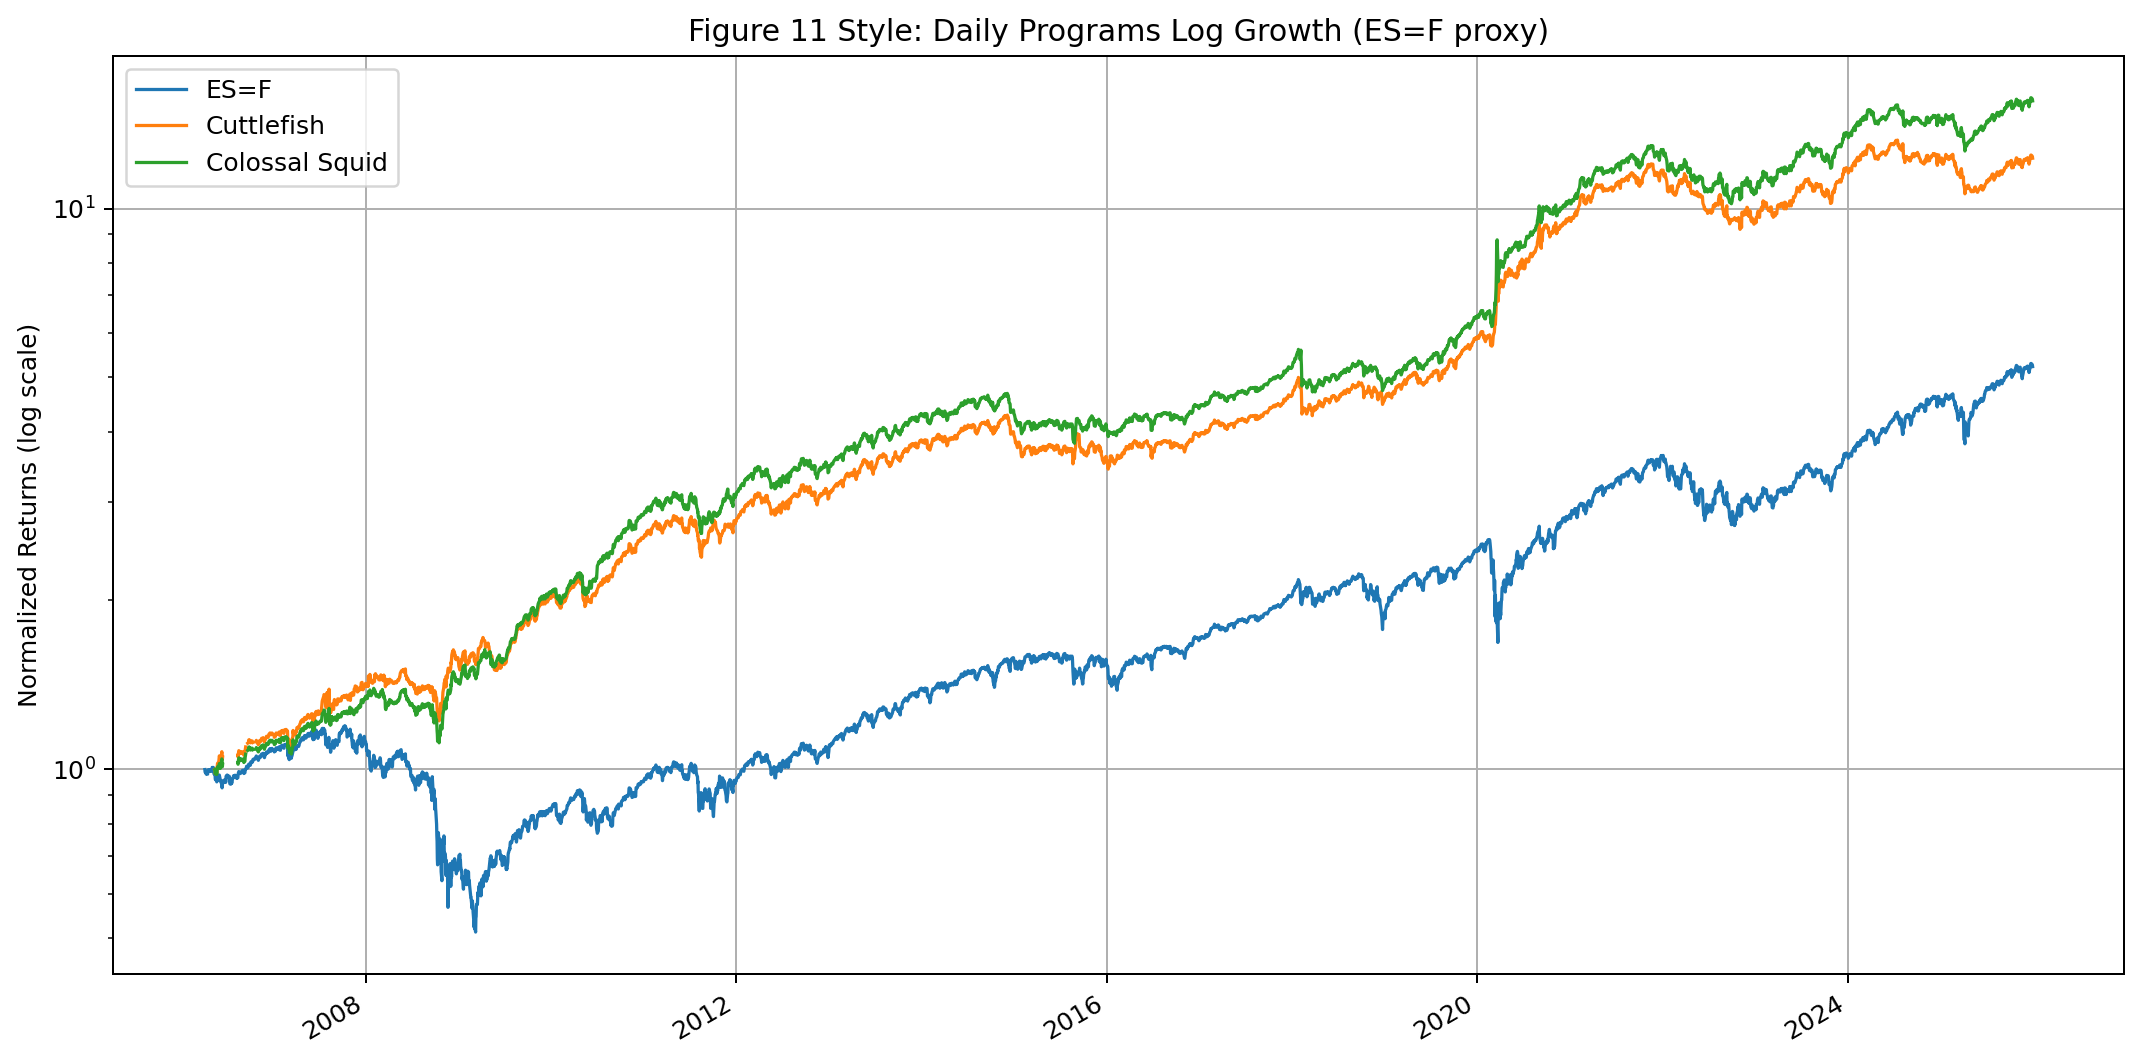

In [296]:
ax = daily_program_growth.plot(logy=True, figsize=(12, 6), linewidth=1.3, grid=True)
ax.set_title(f'Figure 11 Style: Daily Programs Log Growth ({PRIMARY_EQUITY_PROXY} proxy)')
ax.set_ylabel('Normalized Returns (log scale)')
ax.set_xlabel('')
plt.tight_layout()


### Figure 12 Style: Daily Programs Underwater

This underwater view is the drawdown counterpart to the daily log-growth chart above. The key comparison is whether the refined daily model reduces the worst losses relative to the base daily model without giving up too much upside.


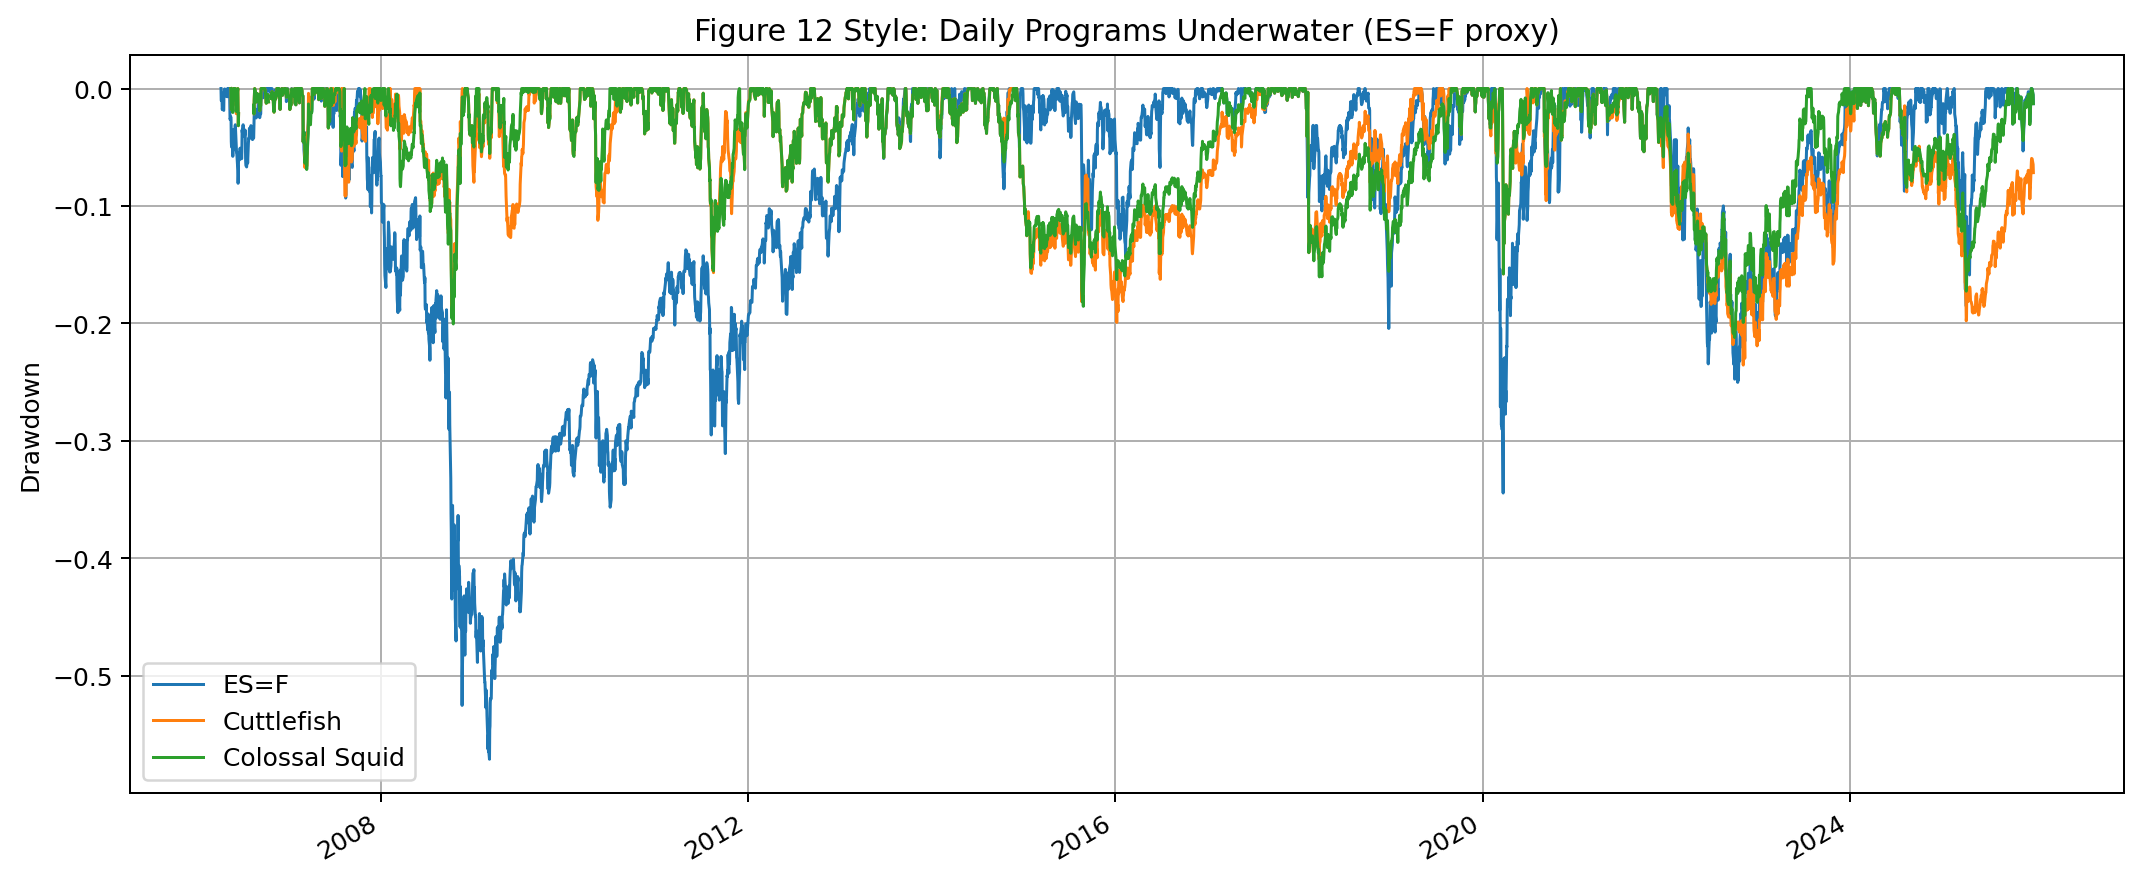

In [297]:
ax = daily_program_drawdowns.plot(figsize=(12, 5), linewidth=1.2, grid=True)
ax.set_title(f'Figure 12 Style: Daily Programs Underwater ({PRIMARY_EQUITY_PROXY} proxy)')
ax.set_ylabel('Drawdown')
ax.set_xlabel('')
plt.tight_layout()


### Table 4 Style: Refined Program Performance

This is the refined-model summary table from the paper. As with Table 3, we compute the statistics on the common overlap of all displayed series so the comparison is internally consistent.


In [298]:
table_4_raw = pd.DataFrame(
    {
        PRIMARY_EQUITY_PROXY: summarize_performance(refined_common_returns[PRIMARY_EQUITY_PROXY]),
        'Giant Squid': summarize_performance(
            refined_common_returns['Giant Squid'],
            turnover=weekly_refined_turnover.reindex(refined_common_returns.index),
        ),
        'Jumbo Squid': summarize_performance(
            refined_common_returns['Jumbo Squid'],
            turnover=weekly_long_only_turnover.reindex(refined_common_returns.index),
        ),
        'Colossal Squid': summarize_performance(
            refined_common_returns['Colossal Squid'],
            turnover=daily_refined_turnover.reindex(refined_common_returns.index),
        ),
    }
)

table_4_display = pd.DataFrame(
    {
        PRIMARY_EQUITY_PROXY: [
            100 * table_4_raw.loc['annualized_return', PRIMARY_EQUITY_PROXY],
            100 * table_4_raw.loc['annualized_volatility', PRIMARY_EQUITY_PROXY],
            100 * abs(table_4_raw.loc['max_drawdown', PRIMARY_EQUITY_PROXY]),
            table_4_raw.loc['sharpe_ratio', PRIMARY_EQUITY_PROXY],
            table_4_raw.loc['sortino_ratio', PRIMARY_EQUITY_PROXY],
            pd.NA,
        ],
        'L/S ES Weekly: Giant Squid': [
            100 * table_4_raw.loc['annualized_return', 'Giant Squid'],
            100 * table_4_raw.loc['annualized_volatility', 'Giant Squid'],
            100 * abs(table_4_raw.loc['max_drawdown', 'Giant Squid']),
            table_4_raw.loc['sharpe_ratio', 'Giant Squid'],
            table_4_raw.loc['sortino_ratio', 'Giant Squid'],
            100 * table_4_raw.loc['turnover', 'Giant Squid'],
        ],
        'Long ES Weekly: Jumbo Squid': [
            100 * table_4_raw.loc['annualized_return', 'Jumbo Squid'],
            100 * table_4_raw.loc['annualized_volatility', 'Jumbo Squid'],
            100 * abs(table_4_raw.loc['max_drawdown', 'Jumbo Squid']),
            table_4_raw.loc['sharpe_ratio', 'Jumbo Squid'],
            table_4_raw.loc['sortino_ratio', 'Jumbo Squid'],
            100 * table_4_raw.loc['turnover', 'Jumbo Squid'],
        ],
        'L/S ES Daily: Colossal Squid': [
            100 * table_4_raw.loc['annualized_return', 'Colossal Squid'],
            100 * table_4_raw.loc['annualized_volatility', 'Colossal Squid'],
            100 * abs(table_4_raw.loc['max_drawdown', 'Colossal Squid']),
            table_4_raw.loc['sharpe_ratio', 'Colossal Squid'],
            table_4_raw.loc['sortino_ratio', 'Colossal Squid'],
            100 * table_4_raw.loc['turnover', 'Colossal Squid'],
        ],
    },
    index=[
        'Annualized Returns (%)',
        'Annualized Volatility (%)',
        'Max Drawdown (%)',
        'Sharpe Ratio',
        'Sortino Ratio',
        'Turnover (%)',
    ],
)
table_4_display.round(2)


,ES=F,L/S ES Weekly: Giant Squid,Long ES Weekly: Jumbo Squid,L/S ES Daily: Colossal Squid
Annualized Returns (%),8.839071,13.41,13.75,15.19
Annualized Volatility (%),19.839166,13.43,13.22,13.57
Max Drawdown (%),57.113402,22.94,22.94,21.20
Sharpe Ratio,0.445536,1.00,1.04,1.12
Sortino Ratio,0.624084,1.43,1.49,1.61
Turnover (%),<NA>,2.65,2.51,8.96


## 15. Proxy Realism And Threshold Calibration

At this point the notebook can reproduce the full signal section and the base/refined program figures, but one practical limitation remains: Yahoo does not expose a clean expired quarterly ES contract history back to 2006. In practice we can query the continuous `ES=F` series and some live `.CME` contract symbols, but not a robust archive of expired quarterly contracts suitable for an exact historical roll.

Because of that limitation, this section does two things:
1. compare `ES=F` and `SPY` as equity proxies against the paper's published results,
2. search a small grid of `mc` and `Vc` values to see which refined-model thresholds fit the paper best under the current proxy setup.


In [299]:
paper_table_3_targets = {
    PRIMARY_EQUITY_PROXY: {
        'annualized_return': 0.1077,
        'annualized_volatility': 0.1726,
        'max_drawdown': 0.5519,
        'sharpe_ratio': 0.54,
        'sortino_ratio': 0.44,
    },
    'Squid': {
        'annualized_return': 0.1584,
        'annualized_volatility': 0.1349,
        'max_drawdown': 0.2409,
        'sharpe_ratio': 1.06,
        'sortino_ratio': 1.18,
        'turnover': 0.0446,
    },
    'Cuttlefish': {
        'annualized_return': 0.1759,
        'annualized_volatility': 0.1342,
        'max_drawdown': 0.3010,
        'sharpe_ratio': 1.20,
        'sortino_ratio': 1.42,
        'turnover': 0.1545,
    },
}

paper_table_4_targets = {
    PRIMARY_EQUITY_PROXY: {
        'annualized_return': 0.1077,
        'annualized_volatility': 0.1726,
        'max_drawdown': 0.5519,
        'sharpe_ratio': 0.54,
        'sortino_ratio': 0.44,
    },
    'Giant Squid': {
        'annualized_return': 0.2101,
        'annualized_volatility': 0.1534,
        'max_drawdown': 0.2414,
        'sharpe_ratio': 1.27,
        'sortino_ratio': 1.69,
        'turnover': 0.0823,
    },
    'Jumbo Squid': {
        'annualized_return': 0.1940,
        'annualized_volatility': 0.1372,
        'max_drawdown': 0.2409,
        'sharpe_ratio': 1.30,
        'sortino_ratio': 1.60,
        'turnover': 0.0608,
    },
    'Colossal Squid': {
        'annualized_return': 0.2109,
        'annualized_volatility': 0.1490,
        'max_drawdown': 0.2971,
        'sharpe_ratio': 1.31,
        'sortino_ratio': 1.73,
        'turnover': 0.2659,
    },
}

def normalized_error(actual: float, target: float) -> float:
    scale = max(abs(target), 0.01)
    return abs(actual - target) / scale


def build_proxy_package(equity_label: str, slope_threshold: float, vix_threshold: float):
    equity_series = proxy_returns[[equity_label]].rename(columns={equity_label: 'ES'})
    two_asset_returns = pd.concat(
        [
            equity_series,
            spvxtstr[['spvxtstr_return']].rename(columns={'spvxtstr_return': 'SPVXTSTR'}),
        ],
        axis=1,
        sort=False,
    )
    three_asset_returns = pd.concat(
        [equity_series, vx_returns],
        axis=1,
        sort=False,
    )

    same_day = summarize_bucket_returns(two_asset_returns.rename(columns={'ES': equity_label}), daily_signal['dislocation_bucket_raw'])
    next_day = summarize_bucket_returns(two_asset_returns.rename(columns={'ES': equity_label}), daily_signal['dislocation_bucket_raw'], future_periods=1)

    daily_refined = build_refined_program_weights(daily_signal, name='Colossal Squid', slope_threshold=slope_threshold, vix_threshold=vix_threshold, allow_short_es=True)
    weekly_refined = build_refined_program_weights(weekly_signal, name='Giant Squid', slope_threshold=slope_threshold, vix_threshold=vix_threshold, allow_short_es=True)
    weekly_long_only = build_refined_program_weights(weekly_signal, name='Jumbo Squid', slope_threshold=slope_threshold, vix_threshold=vix_threshold, allow_short_es=False)

    giant = combine_weighted_returns(three_asset_returns, weekly_refined, asset_weight_map={'ES': 'weight_es', 'UX1': 'weight_ux1', 'UX3': 'weight_ux3'}, name='Giant Squid')
    jumbo = combine_weighted_returns(three_asset_returns, weekly_long_only, asset_weight_map={'ES': 'weight_es', 'UX1': 'weight_ux1', 'UX3': 'weight_ux3'}, name='Jumbo Squid')
    colossal = combine_weighted_returns(three_asset_returns, daily_refined, asset_weight_map={'ES': 'weight_es', 'UX1': 'weight_ux1', 'UX3': 'weight_ux3'}, name='Colossal Squid')
    cuttlefish = combine_weighted_returns(three_asset_returns, daily_base_weights, asset_weight_map={'ES': 'weight_es', 'UX1': 'weight_ux1', 'UX3': 'weight_ux3'}, name='Cuttlefish')
    squid = combine_weighted_returns(three_asset_returns, weekly_base_weights, asset_weight_map={'ES': 'weight_es', 'UX1': 'weight_ux1', 'UX3': 'weight_ux3'}, name='Squid')

    base_common = pd.concat([proxy_returns[[equity_label]], cuttlefish, squid], axis=1, sort=False).dropna(how='any')
    refined_common = pd.concat([proxy_returns[[equity_label]], giant, jumbo, colossal], axis=1, sort=False).dropna(how='any')

    base_table = pd.DataFrame(
        {
            equity_label: summarize_performance(base_common[equity_label]),
            'Squid': summarize_performance(base_common['Squid'], turnover=weekly_base_turnover.reindex(base_common.index)),
            'Cuttlefish': summarize_performance(base_common['Cuttlefish'], turnover=daily_base_turnover.reindex(base_common.index)),
        }
    )
    refined_table = pd.DataFrame(
        {
            equity_label: summarize_performance(refined_common[equity_label]),
            'Giant Squid': summarize_performance(refined_common['Giant Squid'], turnover=build_turnover_series(weekly_refined, weight_columns=['weight_es', 'weight_ux1', 'weight_ux3']).reindex(refined_common.index)),
            'Jumbo Squid': summarize_performance(refined_common['Jumbo Squid'], turnover=build_turnover_series(weekly_long_only, weight_columns=['weight_es', 'weight_ux1', 'weight_ux3']).reindex(refined_common.index)),
            'Colossal Squid': summarize_performance(refined_common['Colossal Squid'], turnover=build_turnover_series(daily_refined, weight_columns=['weight_es', 'weight_ux1', 'weight_ux3']).reindex(refined_common.index)),
        }
    )

    high_mask = daily_signal['dislocation_bucket_raw'].eq('High Dislocation (5-7)')
    next_day_high_stats = summarize_conditional_returns(two_asset_returns.rename(columns={'ES': equity_label}).shift(-1), high_mask)

    return {
        'same_day': same_day,
        'next_day': next_day,
        'base_table': base_table,
        'refined_table': refined_table,
        'next_day_high_stats': next_day_high_stats,
    }


def score_proxy_package(equity_label: str, package: dict[str, pd.DataFrame]) -> dict[str, float]:
    same_day_error = (100 * package['same_day'][equity_label] - paper_table_2[f'{PRIMARY_EQUITY_PROXY} avg return (paper %)']).abs().mean()
    next_day_error = (100 * package['next_day'][equity_label] - pd.Series([0.0360, 0.0060, 0.0729], index=DEFAULT_BUCKET_ORDER)).abs().mean()
    high_bucket_error = (
        abs(100 * package['next_day_high_stats'].loc[equity_label, 'mean'] - 0.0729)
        + abs(100 * package['next_day_high_stats'].loc[equity_label, 'median'] - 0.1569)
    ) / 2.0

    fit_score = 0.0
    for program, target_metrics in paper_table_3_targets.items():
        actual_column = equity_label if program == PRIMARY_EQUITY_PROXY else program
        for metric, target in target_metrics.items():
            fit_score += normalized_error(abs(package['base_table'].loc[metric, actual_column]) if metric == 'max_drawdown' else package['base_table'].loc[metric, actual_column], target)
    for program, target_metrics in paper_table_4_targets.items():
        actual_column = equity_label if program == PRIMARY_EQUITY_PROXY else program
        for metric, target in target_metrics.items():
            fit_score += normalized_error(abs(package['refined_table'].loc[metric, actual_column]) if metric == 'max_drawdown' else package['refined_table'].loc[metric, actual_column], target)

    return {
        'same_day_bucket_mae_pct': same_day_error,
        'next_day_bucket_mae_pct': next_day_error,
        'high_bucket_mean_median_mae_pct': high_bucket_error,
        'table_fit_score': fit_score,
    }


In [300]:
proxy_packages = {proxy: build_proxy_package(proxy, SLOPE_THRESHOLD, VIX_THRESHOLD) for proxy in PROXY_CANDIDATES}
proxy_fit = pd.DataFrame({proxy: score_proxy_package(proxy, package) for proxy, package in proxy_packages.items()}).T
proxy_fit = proxy_fit.sort_values(['table_fit_score', 'same_day_bucket_mae_pct'])
proxy_fit


,same_day_bucket_mae_pct,next_day_bucket_mae_pct,high_bucket_mean_median_mae_pct,table_fit_score
SPY,0.015564,0.010100,0.030404,8.374192
ES=F,0.018683,0.010202,0.030138,8.397274


### Threshold Search For `mc` And `Vc`

The grid below is not meant to overfit the paper. It is meant to show how sensitive the refined-model results are to broad threshold choices. The score is a crude normalized distance from the paper's Table 3 and Table 4 metrics, so lower is better, but the main value is seeing whether there is a stable neighborhood of parameters rather than one fragile optimum.


In [301]:
slope_grid = [-0.20, -0.15, -0.10, -0.075, -0.05, -0.025]
vix_grid = [25.0, 27.5, 30.0, 32.5, 35.0, 40.0]
threshold_rows = []

for slope_threshold in slope_grid:
    for vix_threshold in vix_grid:
        package = build_proxy_package(PRIMARY_EQUITY_PROXY, slope_threshold, vix_threshold)
        scores = score_proxy_package(PRIMARY_EQUITY_PROXY, package)
        threshold_rows.append(
            {
                'slope_threshold': slope_threshold,
                'vix_threshold': vix_threshold,
                **scores,
            }
        )

threshold_search = pd.DataFrame(threshold_rows).sort_values('table_fit_score').reset_index(drop=True)
threshold_search.head(10)


,slope_threshold,vix_threshold,same_day_bucket_mae_pct,next_day_bucket_mae_pct,high_bucket_mean_median_mae_pct,table_fit_score
0,-0.100,25.0,0.018683,0.010202,0.030138,7.927917
1,-0.150,25.0,0.018683,0.010202,0.030138,8.053542
2,-0.075,25.0,0.018683,0.010202,0.030138,8.115838
3,-0.100,27.5,0.018683,0.010202,0.030138,8.122919
4,-0.150,27.5,0.018683,0.010202,0.030138,8.198553
5,-0.100,35.0,0.018683,0.010202,0.030138,8.231757
6,-0.100,40.0,0.018683,0.010202,0.030138,8.235587
7,-0.100,32.5,0.018683,0.010202,0.030138,8.321060
8,-0.200,25.0,0.018683,0.010202,0.030138,8.322636
9,-0.150,35.0,0.018683,0.010202,0.030138,8.377822


### Optimized-Threshold Strategy Charts

The threshold search produces a ranked list of candidate `mc` and `Vc` values. The next cells take the top row from that table and turn it into actual strategy return streams so the optimization step is not just abstract scoring.

These charts are useful for testing whether the best-scoring parameters only improve the summary tables on paper, or whether they also produce visibly different return paths.


In [302]:
best_threshold = threshold_search.iloc[0]
OPTIMIZED_SLOPE_THRESHOLD = float(best_threshold['slope_threshold'])
OPTIMIZED_VIX_THRESHOLD = float(best_threshold['vix_threshold'])

optimized_daily_refined_weights = build_refined_program_weights(
    daily_signal,
    name='Optimized Colossal Squid',
    slope_threshold=OPTIMIZED_SLOPE_THRESHOLD,
    vix_threshold=OPTIMIZED_VIX_THRESHOLD,
    allow_short_es=True,
)
optimized_weekly_refined_weights = build_refined_program_weights(
    weekly_signal,
    name='Optimized Giant Squid',
    slope_threshold=OPTIMIZED_SLOPE_THRESHOLD,
    vix_threshold=OPTIMIZED_VIX_THRESHOLD,
    allow_short_es=True,
)
optimized_weekly_long_only_weights = build_refined_program_weights(
    weekly_signal,
    name='Optimized Jumbo Squid',
    slope_threshold=OPTIMIZED_SLOPE_THRESHOLD,
    vix_threshold=OPTIMIZED_VIX_THRESHOLD,
    allow_short_es=False,
)

optimized_daily_refined_turnover = build_turnover_series(
    optimized_daily_refined_weights,
    weight_columns=['weight_es', 'weight_ux1', 'weight_ux3'],
)
optimized_weekly_refined_turnover = build_turnover_series(
    optimized_weekly_refined_weights,
    weight_columns=['weight_es', 'weight_ux1', 'weight_ux3'],
)
optimized_weekly_long_only_turnover = build_turnover_series(
    optimized_weekly_long_only_weights,
    weight_columns=['weight_es', 'weight_ux1', 'weight_ux3'],
)

optimized_giant_returns = combine_weighted_returns(
    s1_asset_returns,
    optimized_weekly_refined_weights,
    asset_weight_map={'ES': 'weight_es', 'UX1': 'weight_ux1', 'UX3': 'weight_ux3'},
    name='Optimized Giant Squid',
)
optimized_jumbo_returns = combine_weighted_returns(
    s1_asset_returns,
    optimized_weekly_long_only_weights,
    asset_weight_map={'ES': 'weight_es', 'UX1': 'weight_ux1', 'UX3': 'weight_ux3'},
    name='Optimized Jumbo Squid',
)
optimized_colossal_returns = combine_weighted_returns(
    s1_asset_returns,
    optimized_daily_refined_weights,
    asset_weight_map={'ES': 'weight_es', 'UX1': 'weight_ux1', 'UX3': 'weight_ux3'},
    name='Optimized Colossal Squid',
)

optimized_growth_curves = pd.DataFrame(
    {
        PRIMARY_EQUITY_PROXY: build_growth_index(proxy_returns[PRIMARY_EQUITY_PROXY]),
        'Optimized Giant Squid': build_growth_index(optimized_giant_returns),
        'Optimized Jumbo Squid': build_growth_index(optimized_jumbo_returns),
        'Optimized Colossal Squid': build_growth_index(optimized_colossal_returns),
    }
)
optimized_drawdown_curves = optimized_growth_curves.apply(build_drawdown_series)

optimized_refined_common = pd.concat(
    [
        proxy_returns[[PRIMARY_EQUITY_PROXY]],
        optimized_giant_returns.rename('Optimized Giant Squid'),
        optimized_jumbo_returns.rename('Optimized Jumbo Squid'),
        optimized_colossal_returns.rename('Optimized Colossal Squid'),
    ],
    axis=1,
    sort=False,
).dropna(how='any')

optimized_table_4_raw = pd.DataFrame(
    {
        PRIMARY_EQUITY_PROXY: summarize_performance(optimized_refined_common[PRIMARY_EQUITY_PROXY]),
        'Optimized Giant Squid': summarize_performance(
            optimized_refined_common['Optimized Giant Squid'],
            turnover=optimized_weekly_refined_turnover.reindex(optimized_refined_common.index),
        ),
        'Optimized Jumbo Squid': summarize_performance(
            optimized_refined_common['Optimized Jumbo Squid'],
            turnover=optimized_weekly_long_only_turnover.reindex(optimized_refined_common.index),
        ),
        'Optimized Colossal Squid': summarize_performance(
            optimized_refined_common['Optimized Colossal Squid'],
            turnover=optimized_daily_refined_turnover.reindex(optimized_refined_common.index),
        ),
    }
)

optimized_table_4_display = pd.DataFrame(
    {
        PRIMARY_EQUITY_PROXY: [
            100 * optimized_table_4_raw.loc['annualized_return', PRIMARY_EQUITY_PROXY],
            100 * optimized_table_4_raw.loc['annualized_volatility', PRIMARY_EQUITY_PROXY],
            100 * abs(optimized_table_4_raw.loc['max_drawdown', PRIMARY_EQUITY_PROXY]),
            optimized_table_4_raw.loc['sharpe_ratio', PRIMARY_EQUITY_PROXY],
            optimized_table_4_raw.loc['sortino_ratio', PRIMARY_EQUITY_PROXY],
            pd.NA,
        ],
        'Optimized Giant Squid': [
            100 * optimized_table_4_raw.loc['annualized_return', 'Optimized Giant Squid'],
            100 * optimized_table_4_raw.loc['annualized_volatility', 'Optimized Giant Squid'],
            100 * abs(optimized_table_4_raw.loc['max_drawdown', 'Optimized Giant Squid']),
            optimized_table_4_raw.loc['sharpe_ratio', 'Optimized Giant Squid'],
            optimized_table_4_raw.loc['sortino_ratio', 'Optimized Giant Squid'],
            100 * optimized_table_4_raw.loc['turnover', 'Optimized Giant Squid'],
        ],
        'Optimized Jumbo Squid': [
            100 * optimized_table_4_raw.loc['annualized_return', 'Optimized Jumbo Squid'],
            100 * optimized_table_4_raw.loc['annualized_volatility', 'Optimized Jumbo Squid'],
            100 * abs(optimized_table_4_raw.loc['max_drawdown', 'Optimized Jumbo Squid']),
            optimized_table_4_raw.loc['sharpe_ratio', 'Optimized Jumbo Squid'],
            optimized_table_4_raw.loc['sortino_ratio', 'Optimized Jumbo Squid'],
            100 * optimized_table_4_raw.loc['turnover', 'Optimized Jumbo Squid'],
        ],
        'Optimized Colossal Squid': [
            100 * optimized_table_4_raw.loc['annualized_return', 'Optimized Colossal Squid'],
            100 * optimized_table_4_raw.loc['annualized_volatility', 'Optimized Colossal Squid'],
            100 * abs(optimized_table_4_raw.loc['max_drawdown', 'Optimized Colossal Squid']),
            optimized_table_4_raw.loc['sharpe_ratio', 'Optimized Colossal Squid'],
            optimized_table_4_raw.loc['sortino_ratio', 'Optimized Colossal Squid'],
            100 * optimized_table_4_raw.loc['turnover', 'Optimized Colossal Squid'],
        ],
    },
    index=[
        'Annualized Returns (%)',
        'Annualized Volatility (%)',
        'Max Drawdown (%)',
        'Sharpe Ratio',
        'Sortino Ratio',
        'Turnover (%)',
    ],
 )

display(pd.DataFrame(best_threshold).T)
optimized_table_4_display.round(2)


,slope_threshold,vix_threshold,same_day_bucket_mae_pct,next_day_bucket_mae_pct,high_bucket_mean_median_mae_pct,table_fit_score
0,-0.1,25.0,0.018683,0.010202,0.030138,7.927917


,ES=F,Optimized Giant Squid,Optimized Jumbo Squid,Optimized Colossal Squid
Annualized Returns (%),8.839071,14.62,14.39,14.90
Annualized Volatility (%),19.839166,14.39,13.34,14.08
Max Drawdown (%),57.113402,22.94,22.94,22.50
Sharpe Ratio,0.445536,1.02,1.08,1.06
Sortino Ratio,0.624084,1.47,1.55,1.53
Turnover (%),<NA>,3.49,2.76,11.41


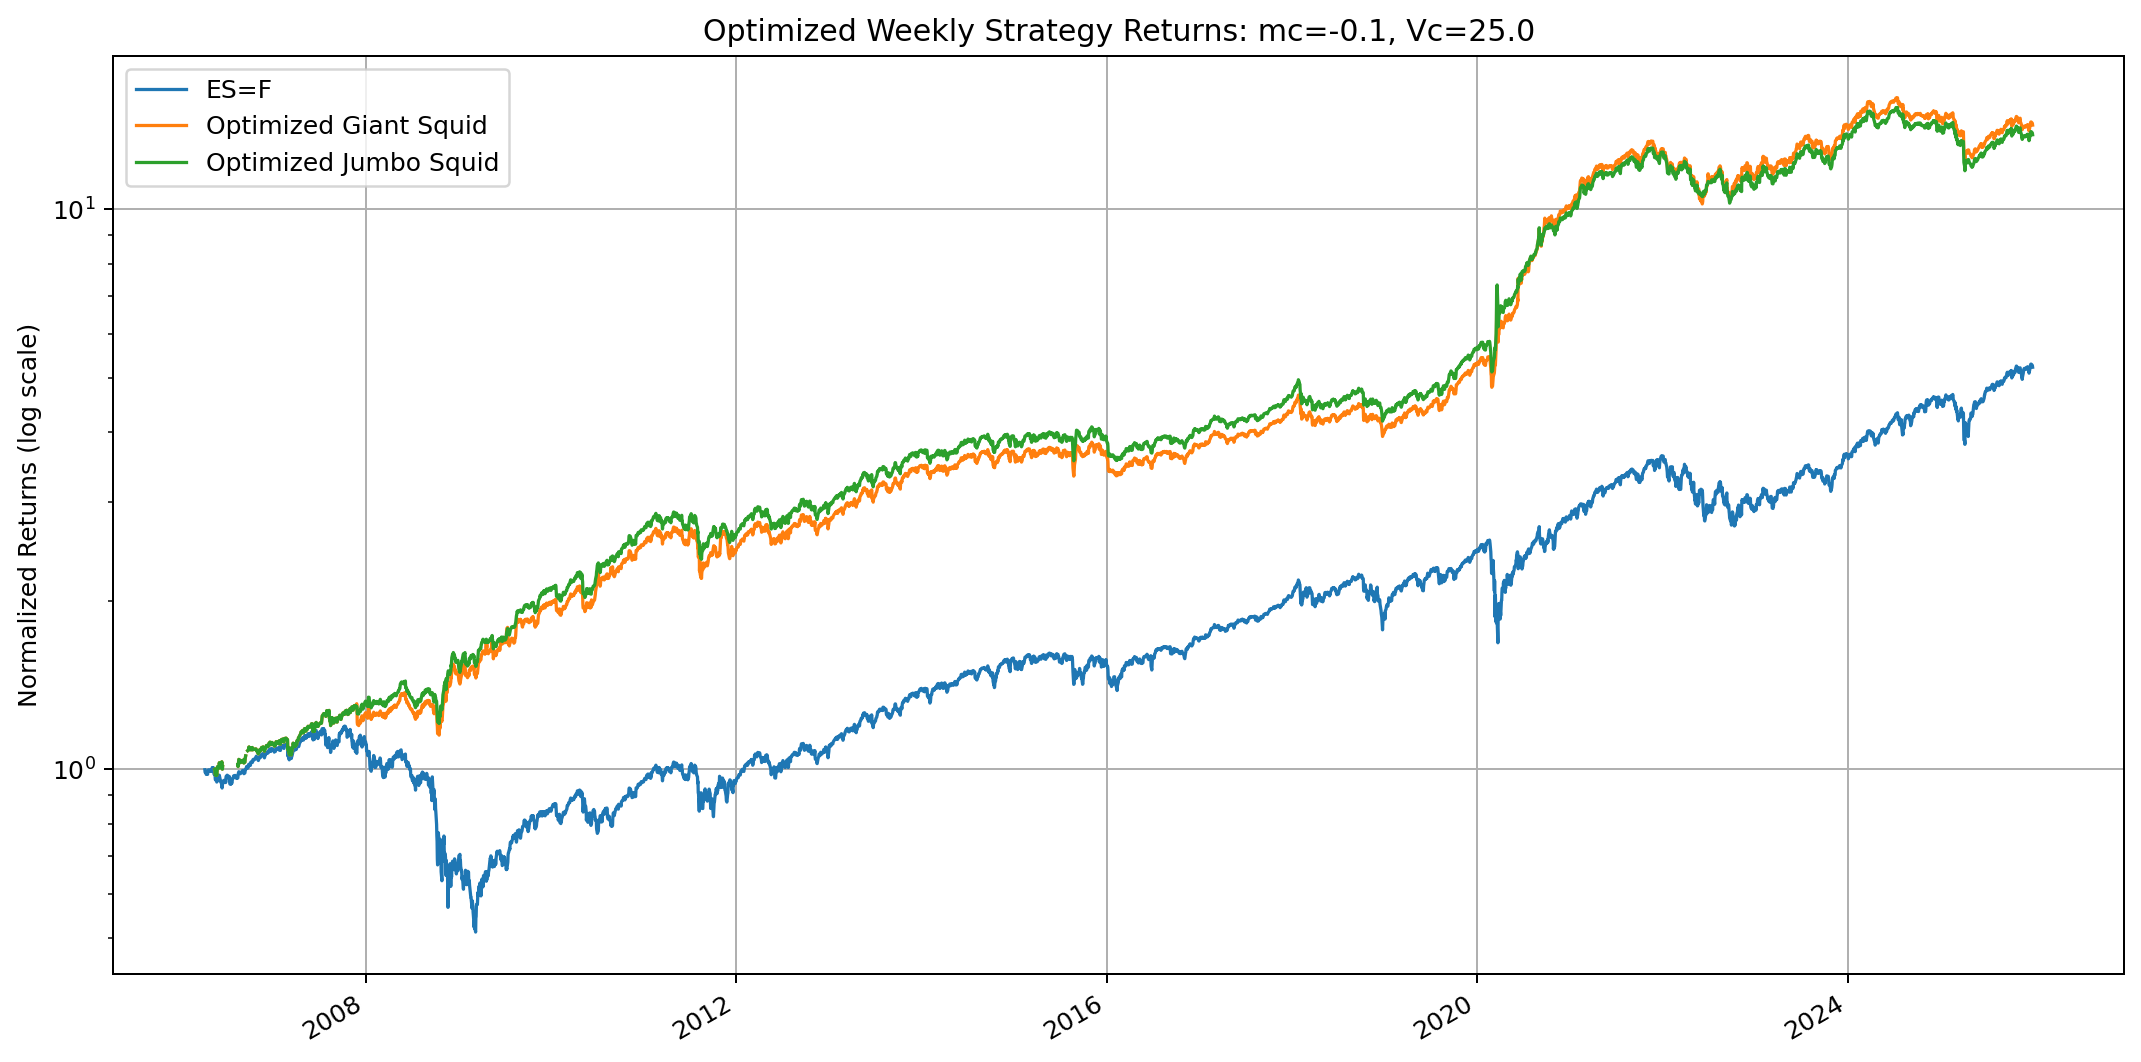

In [303]:
ax = optimized_growth_curves[[PRIMARY_EQUITY_PROXY, 'Optimized Giant Squid', 'Optimized Jumbo Squid']].plot(
    logy=True,
    figsize=(12, 6),
    linewidth=1.3,
    grid=True,
)
ax.set_title(f'Optimized Weekly Strategy Returns: mc={OPTIMIZED_SLOPE_THRESHOLD}, Vc={OPTIMIZED_VIX_THRESHOLD}')
ax.set_ylabel('Normalized Returns (log scale)')
ax.set_xlabel('')
plt.tight_layout()


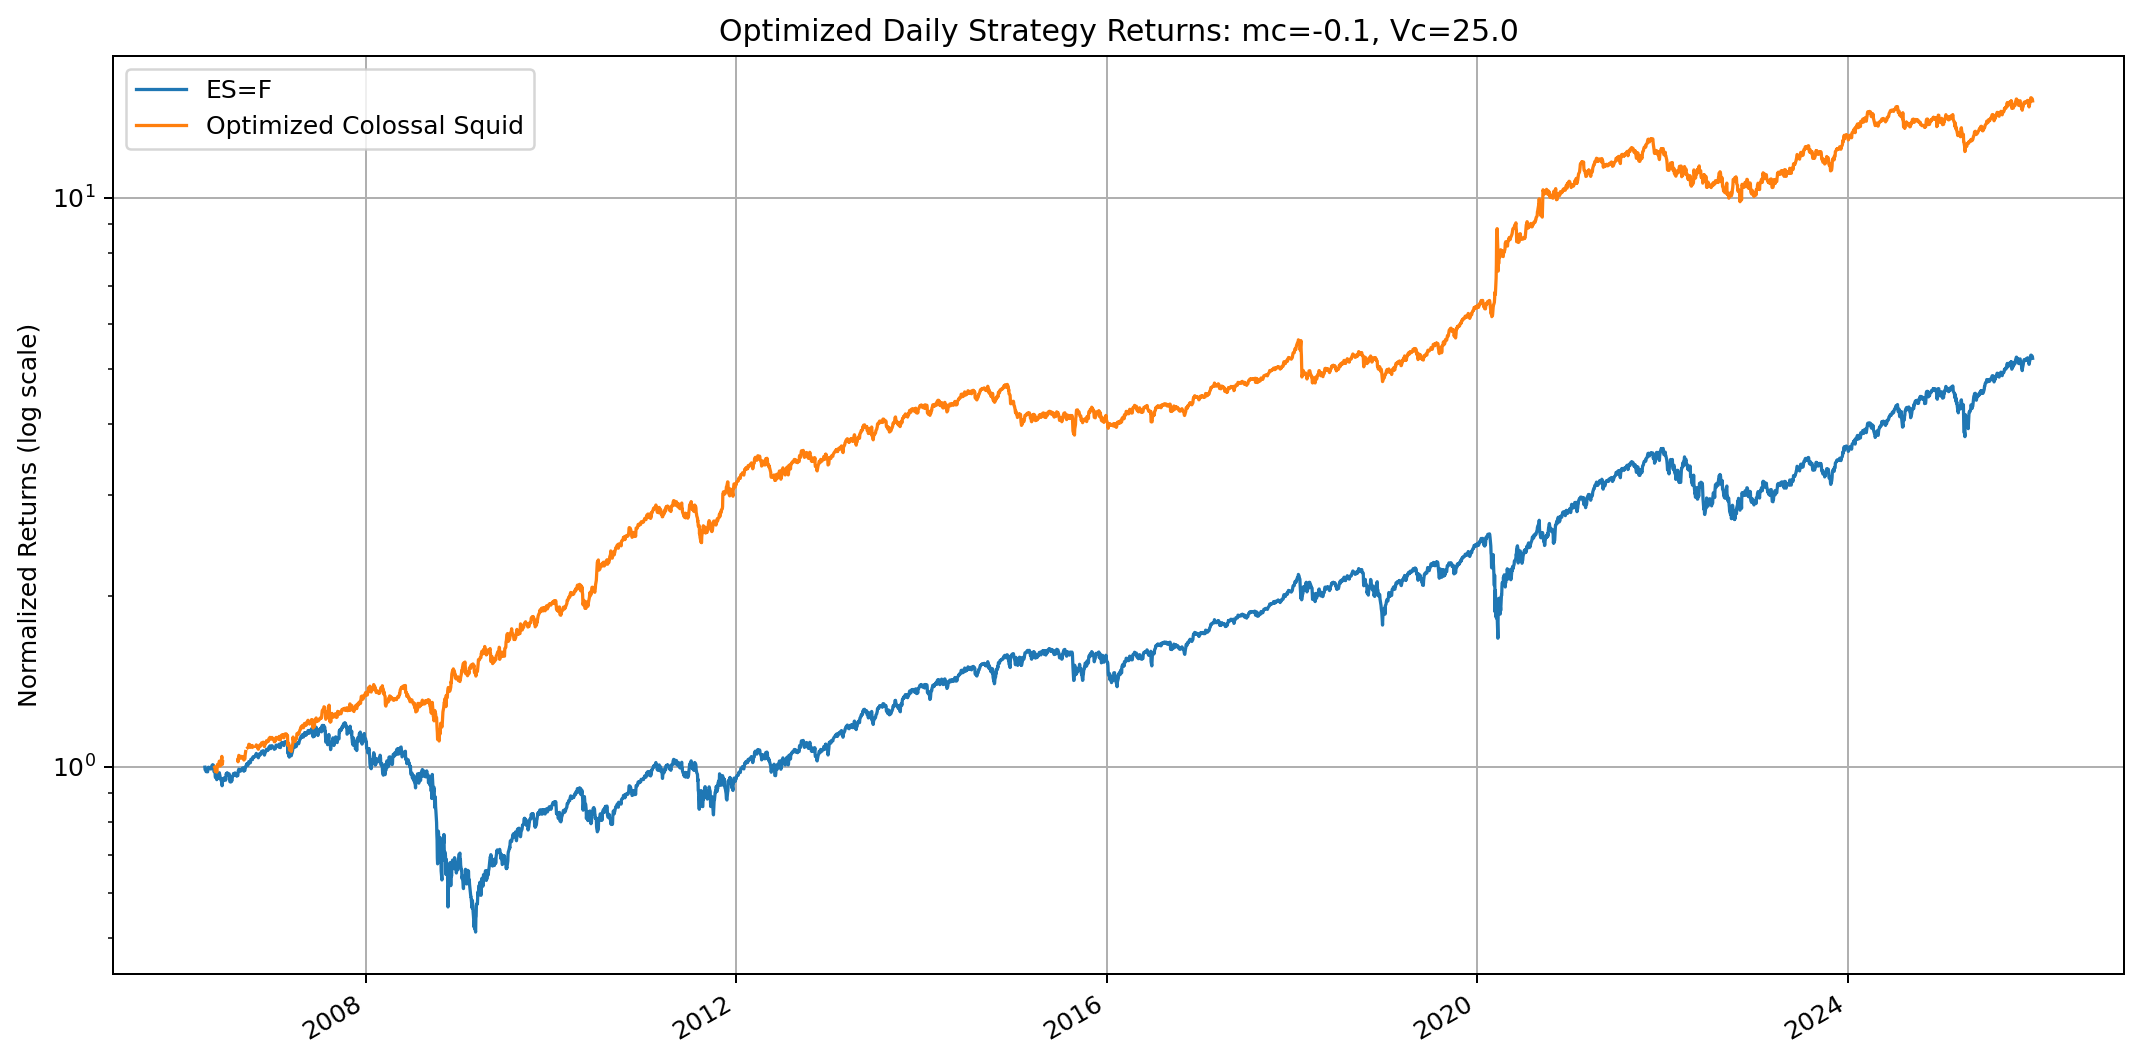

In [304]:
ax = optimized_growth_curves[[PRIMARY_EQUITY_PROXY, 'Optimized Colossal Squid']].plot(
    logy=True,
    figsize=(12, 6),
    linewidth=1.3,
    grid=True,
)
ax.set_title(f'Optimized Daily Strategy Returns: mc={OPTIMIZED_SLOPE_THRESHOLD}, Vc={OPTIMIZED_VIX_THRESHOLD}')
ax.set_ylabel('Normalized Returns (log scale)')
ax.set_xlabel('')
plt.tight_layout()


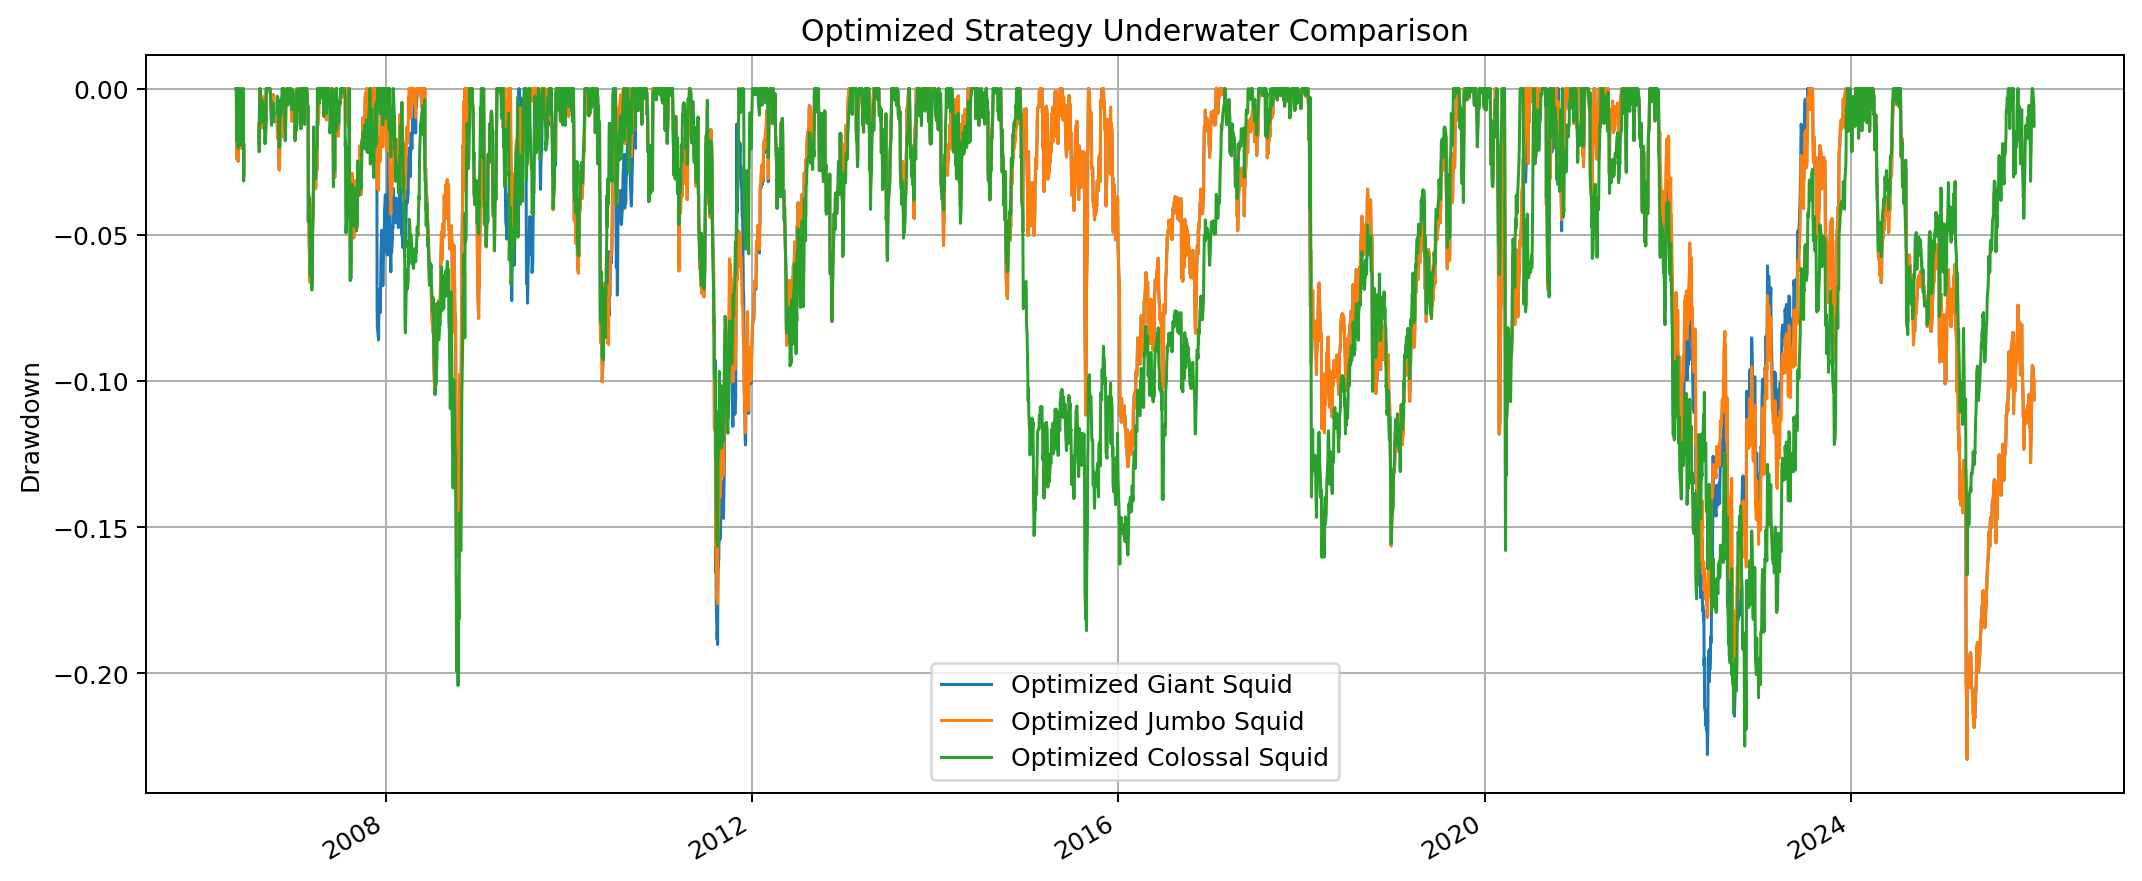

In [305]:
ax = optimized_drawdown_curves[['Optimized Giant Squid', 'Optimized Jumbo Squid', 'Optimized Colossal Squid']].plot(
    figsize=(12, 5),
    linewidth=1.2,
    grid=True,
)
ax.set_title('Optimized Strategy Underwater Comparison')
ax.set_ylabel('Drawdown')
ax.set_xlabel('')
plt.tight_layout()


## 16. Export Investable Weights

The final step is not a chart but an output artifact: a flat weights file that can be inspected, backtested, or wired into later strategy code. We export all currently implemented programs into one table and then show the latest row for each program so the current allocation state is easy to inspect.


In [306]:
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

strategy_weights = pd.concat(
    [
        s0_weights,
        daily_base_weights,
        weekly_base_weights,
        daily_refined_weights,
        weekly_refined_weights,
        weekly_long_only_weights,
        optimized_daily_refined_weights,
        optimized_weekly_refined_weights,
        optimized_weekly_long_only_weights,
    ]
).reset_index(names='trade_date')

weights_path = EXPORT_DIR / 'strategy_weights.csv'
strategy_weights.to_csv(weights_path, index=False)

latest_weights = (
    strategy_weights.sort_values(['program', 'trade_date'])
    .groupby('program', as_index=False)
    .tail(1)
    .sort_values('program')
)

print(f'Wrote {len(strategy_weights):,} rows to {weights_path}')
latest_weights[[
    'trade_date',
    'program',
    'regime',
    'weight_es',
    'weight_spvxtstr',
    'weight_va',
    'weight_ux1',
    'weight_ux3',
    'gross_exposure',
    'net_exposure',
]]


Wrote 44,730 rows to C:\Users\rodri\git\squid-replication\data\derived\strategy_weights.csv


,trade_date,program,regime,weight_es,weight_spvxtstr,weight_va,weight_ux1,weight_ux3,gross_exposure,net_exposure
19879,2025-12-31,Colossal Squid,base,1.0,<NA>,0.0,-0.0,0.0,1.0,1.0
9939,2025-12-31,Cuttlefish,base,1.0,<NA>,0.0,-0.0,0.0,1.0,1.0
24849,2025-12-31,Giant Squid,base,1.0,<NA>,0.0,-0.0,0.0,1.0,1.0
29819,2025-12-31,Jumbo Squid,base,1.0,<NA>,0.0,-0.0,0.0,1.0,1.0
34789,2025-12-31,Optimized Colossal Squid,base,1.0,<NA>,0.0,-0.0,0.0,1.0,1.0
39759,2025-12-31,Optimized Giant Squid,base,1.0,<NA>,0.0,-0.0,0.0,1.0,1.0
44729,2025-12-31,Optimized Jumbo Squid,base,1.0,<NA>,0.0,-0.0,0.0,1.0,1.0
4969,2025-12-31,S0,base,1.0,0.0,<NA>,<NA>,<NA>,1.0,1.0
14909,2025-12-31,Squid,base,1.0,<NA>,0.0,-0.0,0.0,1.0,1.0


## 17. Next Steps

After this notebook stage, the natural follow-ons are:
1. Decide whether `ES=F` or `SPY` should remain the main notebook proxy based on the fit diagnostics above.
2. Promote the chosen `mc` and `Vc` pair from exploratory calibration into the fixed notebook defaults.
3. Source or build a better historical ES series if we want to move beyond the current Yahoo proxy limitation.
4. Decide which outputs should move from notebook cells into reusable package code once the replication is stable.
